In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Environment loaded successfully.")

Environment loaded successfully.


In [2]:
csv_files = glob.glob("**/*.csv", recursive=True)

print("CSV files found:")
for f in csv_files:
    print(" -", f)

CSV files found:


In [3]:
candidate_files = []

for file in csv_files:
    try:
        temp = pd.read_csv(file, nrows=5)
        cols = set(temp.columns)

        required_any = {
            "fault_type",
            "actual_anomaly",
            "scenario_id"
        }

        if len(required_any.intersection(cols)) >= 2:
            candidate_files.append(file)

    except Exception:
        pass

print("Possible fault datasets:")
for f in candidate_files:
    print(" -", f)

Possible fault datasets:


In [6]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nCSV files under current project:")
for file in Path.cwd().rglob("*.csv"):
    print(file)

Current working directory:
c:\Users\LENOVO\OneDrive\Desktop\SIH_SOLUTION_73\notebooks

CSV files under current project:


In [8]:
from pathlib import Path

# Project structure:
# SIH_SOLUTION_73/
# ├── data/
# └── notebooks/

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:")
print(PROJECT_ROOT)

print("\nData directory:")
print(DATA_DIR)

print("\nCSV files found:")
csv_files = list(DATA_DIR.glob("*.csv"))

print("Number of CSV files:", len(csv_files))

for i, file in enumerate(csv_files):
    print(f"{i}: {file.name}")
    

Project root:
c:\Users\LENOVO\OneDrive\Desktop\SIH_SOLUTION_73

Data directory:
c:\Users\LENOVO\OneDrive\Desktop\SIH_SOLUTION_73\data

CSV files found:
Number of CSV files: 8
0: anomaly_results.csv
1: detector_metrics.csv
2: engineered_weather.csv
3: fault_detection_results.csv
4: per_fault_detection.csv
5: per_fault_metrics.csv
6: synthetic_fault_dataset.csv
7: weather.csv


In [9]:
for file in csv_files:
    try:
        temp = pd.read_csv(file, nrows=5)

        print("\n" + "=" * 70)
        print("FILE:", file.name)
        print("COLUMNS:")
        print(temp.columns.tolist())

    except Exception as e:
        print("\nCould not read:", file.name)
        print("Error:", e)


FILE: anomaly_results.csv
COLUMNS:
['year', 'month', 'day', 'hour', 'temp', 'temp_source', 'rhum', 'rhum_source', 'prcp', 'prcp_source', 'wdir', 'wdir_source', 'wspd', 'wspd_source', 'pres', 'pres_source', 'cldc', 'cldc_source', 'coco', 'coco_source', 'timestamp', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'temp_stat_anomaly', 'rhum_stat_anomaly', 'wspd_stat_anomaly', 'pres_stat_anomaly', 'statistical_anomaly', 'missing_anomaly', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid', 'rule_anomaly', 'if_prediction', '

In [10]:
# Inspect the synthetic fault dataset specifically

FAULT_DATA_PATH = DATA_DIR / "synthetic_fault_dataset.csv"

fault_df = pd.read_csv(FAULT_DATA_PATH)

print("Loaded:", FAULT_DATA_PATH)
print("Shape:", fault_df.shape)

print("\nColumns:")
for i, col in enumerate(fault_df.columns):
    print(f"{i}: {col}")

print("\nData types:")
print(fault_df.dtypes)

print("\nFirst 5 rows:")
display(fault_df.head())

Loaded: c:\Users\LENOVO\OneDrive\Desktop\SIH_SOLUTION_73\data\synthetic_fault_dataset.csv
Shape: (7200, 75)

Columns:
0: year
1: month
2: day
3: hour
4: temp
5: temp_source
6: rhum
7: rhum_source
8: prcp
9: prcp_source
10: wdir
11: wdir_source
12: wspd
13: wspd_source
14: pres
15: pres_source
16: cldc
17: cldc_source
18: coco
19: coco_source
20: timestamp
21: hour_sin
22: hour_cos
23: month_sin
24: month_cos
25: day_of_year
26: wdir_sin
27: wdir_cos
28: temp_diff
29: rhum_diff
30: prcp_diff
31: wspd_diff
32: pres_diff
33: temp_rolling_mean_24h
34: temp_rolling_std_24h
35: rhum_rolling_mean_24h
36: rhum_rolling_std_24h
37: wspd_rolling_mean_24h
38: wspd_rolling_std_24h
39: pres_rolling_mean_24h
40: pres_rolling_std_24h
41: temp_deviation
42: rhum_deviation
43: wspd_deviation
44: pres_deviation
45: temp_mad_score
46: rhum_mad_score
47: wspd_mad_score
48: pres_mad_score
49: temp_stat_anomaly
50: rhum_stat_anomaly
51: wspd_stat_anomaly
52: pres_stat_anomaly
53: statistical_anomaly
54: miss

,year,month,day,hour,temp,temp_source,rhum,rhum_source,prcp,prcp_source,...,rule_score,missing_score,if_score_norm,stat_score_norm,fusion_score,final_anomaly,candidate_anomaly,fault_type,fault_sensor,scenario_id
0,2024,6,21,9,28.6,isd_lite,83.0,isd_lite,0.0,metno_forecast,...,0,0,0.295454,0.171153,0.192858,False,False,normal,NaN,0
1,2024,6,21,10,28.6,metno_forecast,82.0,metno_forecast,0.0,metno_forecast,...,0,0,0.204195,0.121190,0.134304,False,False,normal,NaN,0
2,2024,6,21,11,28.4,metno_forecast,84.0,metno_forecast,0.1,metno_forecast,...,0,0,0.219898,0.129491,0.144276,False,False,normal,NaN,0
3,2024,6,21,12,30.4,isd_lite,83.0,isd_lite,0.3,metno_forecast,...,0,0,0.228209,0.109332,0.140960,False,False,normal,NaN,0
4,2024,6,21,13,26.0,metno_forecast,93.0,metno_forecast,1.3,metno_forecast,...,0,0,0.332352,0.069013,0.173713,False,False,normal,NaN,0


In [11]:
# Basic root-cause target validation

print("fault_type present:", "fault_type" in fault_df.columns)
print("actual_anomaly present:", "actual_anomaly" in fault_df.columns)
print("scenario_id present:", "scenario_id" in fault_df.columns)

if "fault_type" in fault_df.columns:
    print("\nFault type distribution:")
    print(fault_df["fault_type"].value_counts(dropna=False))

if "actual_anomaly" in fault_df.columns:
    print("\nActual anomaly distribution:")
    print(fault_df["actual_anomaly"].value_counts(dropna=False))

if "scenario_id" in fault_df.columns:
    print("\nNumber of scenarios:")
    print(fault_df["scenario_id"].nunique())

    print("\nFault types within each scenario:")
    print(
        fault_df.groupby("scenario_id")["fault_type"]
        .unique()
    )

fault_type present: True
actual_anomaly present: False
scenario_id present: True

Fault type distribution:
fault_type
normal          1200
spike           1200
bias            1200
drift           1200
stuck_sensor    1200
missing         1200
Name: count, dtype: int64

Number of scenarios:
300

Fault types within each scenario:
scenario_id
0       [normal]
1       [normal]
2       [normal]
3       [normal]
4       [normal]
         ...    
295    [missing]
296    [missing]
297    [missing]
298    [missing]
299    [missing]
Name: fault_type, Length: 300, dtype: object


In [12]:
# Validate the scenario structure before creating train/test splits

scenario_summary = (
    fault_df
    .groupby("scenario_id")
    .agg(
        rows=("fault_type", "size"),
        fault_type=("fault_type", "first"),
        unique_fault_types=("fault_type", "nunique")
    )
    .reset_index()
)

print("Number of scenarios:", len(scenario_summary))

print("\nRows per scenario:")
print(scenario_summary["rows"].value_counts().sort_index())

print("\nUnique fault types per scenario:")
print(scenario_summary["unique_fault_types"].value_counts().sort_index())

print("\nScenarios by fault type:")
print(scenario_summary["fault_type"].value_counts().sort_index())

print("\nScenario validation:")
if scenario_summary["unique_fault_types"].max() == 1:
    print("PASS: Every scenario contains exactly one fault type.")
else:
    print("WARNING: Some scenarios contain multiple fault types.")

if scenario_summary["rows"].nunique() == 1:
    print("PASS: All scenarios have the same number of rows.")
else:
    print("WARNING: Scenario sizes are not equal.")

Number of scenarios: 300

Rows per scenario:
rows
24    300
Name: count, dtype: int64

Unique fault types per scenario:
unique_fault_types
1    300
Name: count, dtype: int64

Scenarios by fault type:
fault_type
bias            50
drift           50
missing         50
normal          50
spike           50
stuck_sensor    50
Name: count, dtype: int64

Scenario validation:
PASS: Every scenario contains exactly one fault type.
PASS: All scenarios have the same number of rows.


In [13]:
from sklearn.model_selection import StratifiedGroupKFold

# ---------------------------------------------------------
# Scenario-aware train / validation / test split
# ---------------------------------------------------------

split_df = fault_df.copy()

X_all = split_df.drop(columns=["fault_type"])
y_all = split_df["fault_type"]
groups = split_df["scenario_id"]

print("Total rows:", len(split_df))
print("Total scenarios:", groups.nunique())
print("Total classes:", y_all.nunique())

# First split:
# 5 folds -> approximately 20% of scenarios per fold
# Fold 0 becomes the final TEST set.
sgkf_test = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_val_idx, test_idx = next(
    sgkf_test.split(X_all, y_all, groups)
)

train_val_df = split_df.iloc[train_val_idx].copy()
test_df = split_df.iloc[test_idx].copy()

# Second split:
# Divide the remaining 80% into 4 folds.
# One fold (~20% of total data) becomes VALIDATION.
sgkf_val = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

X_tv = train_val_df.drop(columns=["fault_type"])
y_tv = train_val_df["fault_type"]
groups_tv = train_val_df["scenario_id"]

train_idx, val_idx = next(
    sgkf_val.split(X_tv, y_tv, groups_tv)
)

train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

print("\nSplit sizes:")
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

print("\nScenario counts:")
print("Train scenarios:", train_df["scenario_id"].nunique())
print("Validation scenarios:", val_df["scenario_id"].nunique())
print("Test scenarios:", test_df["scenario_id"].nunique())

Total rows: 7200
Total scenarios: 300
Total classes: 6

Split sizes:
Train rows: 4320
Validation rows: 1440
Test rows: 1440

Scenario counts:
Train scenarios: 180
Validation scenarios: 60
Test scenarios: 60


In [14]:
# ---------------------------------------------------------
# Validate that scenarios do not overlap
# ---------------------------------------------------------

train_scenarios = set(train_df["scenario_id"])
val_scenarios = set(val_df["scenario_id"])
test_scenarios = set(test_df["scenario_id"])

train_val_overlap = train_scenarios & val_scenarios
train_test_overlap = train_scenarios & test_scenarios
val_test_overlap = val_scenarios & test_scenarios

print("Train ∩ Validation:", train_val_overlap)
print("Train ∩ Test:", train_test_overlap)
print("Validation ∩ Test:", val_test_overlap)

assert len(train_val_overlap) == 0
assert len(train_test_overlap) == 0
assert len(val_test_overlap) == 0

print("\nSCENARIO LEAKAGE VALIDATION PASSED")

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()

SCENARIO LEAKAGE VALIDATION PASSED


In [15]:
# ---------------------------------------------------------
# Validate fault-class distribution in each split
# ---------------------------------------------------------

print("TRAIN:")
print(train_df["fault_type"].value_counts().sort_index())

print("\nVALIDATION:")
print(val_df["fault_type"].value_counts().sort_index())

print("\nTEST:")
print(test_df["fault_type"].value_counts().sort_index())

print("\nClass proportions:")

distribution_check = pd.DataFrame({
    "train": train_df["fault_type"].value_counts(normalize=True),
    "validation": val_df["fault_type"].value_counts(normalize=True),
    "test": test_df["fault_type"].value_counts(normalize=True)
}).sort_index()

display(distribution_check)

TRAIN:
fault_type
bias            720
drift           720
missing         720
normal          720
spike           720
stuck_sensor    720
Name: count, dtype: int64

VALIDATION:
fault_type
bias            240
drift           240
missing         240
normal          240
spike           240
stuck_sensor    240
Name: count, dtype: int64

TEST:
fault_type
bias            240
drift           240
missing         240
normal          240
spike           240
stuck_sensor    240
Name: count, dtype: int64

Class proportions:


,train,validation,test
fault_type,,,
bias,0.166667,0.166667,0.166667
drift,0.166667,0.166667,0.166667
missing,0.166667,0.166667,0.166667
normal,0.166667,0.166667,0.166667
spike,0.166667,0.166667,0.166667
stuck_sensor,0.166667,0.166667,0.166667


In [16]:
# ---------------------------------------------------------
# Inspect all columns and identify possible leakage
# ---------------------------------------------------------

print("All columns:")
for i, col in enumerate(fault_df.columns):
    print(f"{i}: {col}")

All columns:
0: year
1: month
2: day
3: hour
4: temp
5: temp_source
6: rhum
7: rhum_source
8: prcp
9: prcp_source
10: wdir
11: wdir_source
12: wspd
13: wspd_source
14: pres
15: pres_source
16: cldc
17: cldc_source
18: coco
19: coco_source
20: timestamp
21: hour_sin
22: hour_cos
23: month_sin
24: month_cos
25: day_of_year
26: wdir_sin
27: wdir_cos
28: temp_diff
29: rhum_diff
30: prcp_diff
31: wspd_diff
32: pres_diff
33: temp_rolling_mean_24h
34: temp_rolling_std_24h
35: rhum_rolling_mean_24h
36: rhum_rolling_std_24h
37: wspd_rolling_mean_24h
38: wspd_rolling_std_24h
39: pres_rolling_mean_24h
40: pres_rolling_std_24h
41: temp_deviation
42: rhum_deviation
43: wspd_deviation
44: pres_deviation
45: temp_mad_score
46: rhum_mad_score
47: wspd_mad_score
48: pres_mad_score
49: temp_stat_anomaly
50: rhum_stat_anomaly
51: wspd_stat_anomaly
52: pres_stat_anomaly
53: statistical_anomaly
54: missing_anomaly
55: rhum_invalid
56: wspd_invalid
57: wdir_invalid
58: prcp_invalid
59: cldc_invalid
60: rule

In [17]:
# ---------------------------------------------------------
# Inspect columns that may contain labels / metadata
# ---------------------------------------------------------

possible_metadata = [
    "fault_type",
    "scenario_id",
    "actual_anomaly",
    "candidate_anomaly",
    "if_anomaly",
    "statistical_anomaly",
    "missing_anomaly",
    "rule_anomaly",
    "combined_anomaly",
    "fault",
    "fault_label",
    "fault_magnitude",
    "injection_type"
]

print("Possible metadata/leakage columns present:")

for col in possible_metadata:
    if col in fault_df.columns:
        print(" -", col)

Possible metadata/leakage columns present:
 - fault_type
 - scenario_id
 - candidate_anomaly
 - if_anomaly
 - statistical_anomaly
 - missing_anomaly
 - rule_anomaly


In [18]:
# ---------------------------------------------------------
# Define columns that must NOT be used as model features
# ---------------------------------------------------------

TARGET_COLUMN = "fault_type"

LEAKAGE_COLUMNS = [
    "fault_type",
    "candidate_anomaly",
    "if_anomaly",
    "statistical_anomaly",
    "missing_anomaly",
    "rule_anomaly",
]

IDENTIFIER_COLUMNS = [
    "scenario_id",
]

TIME_COLUMNS = [
    "timestamp",
    "time",
    "date",
    "year",
    "month",
    "day",
    "hour",
]

EXCLUDE_COLUMNS = (
    LEAKAGE_COLUMNS
    + IDENTIFIER_COLUMNS
    + TIME_COLUMNS
)

print("Columns excluded from model:")
for col in EXCLUDE_COLUMNS:
    if col in fault_df.columns:
        print(" -", col)

Columns excluded from model:
 - fault_type
 - candidate_anomaly
 - if_anomaly
 - statistical_anomaly
 - missing_anomaly
 - rule_anomaly
 - scenario_id
 - timestamp
 - year
 - month
 - day
 - hour


In [19]:
# ---------------------------------------------------------
# Identify numeric model features
# ---------------------------------------------------------

feature_columns = [
    col
    for col in fault_df.columns
    if col not in EXCLUDE_COLUMNS
    and pd.api.types.is_numeric_dtype(fault_df[col])
]

print("Number of candidate numeric features:", len(feature_columns))

print("\nCandidate features:")
for col in feature_columns:
    print(" -", col)

Number of candidate numeric features: 54

Candidate features:
 - temp
 - rhum
 - prcp
 - wdir
 - wspd
 - pres
 - cldc
 - coco
 - hour_sin
 - hour_cos
 - month_sin
 - month_cos
 - day_of_year
 - wdir_sin
 - wdir_cos
 - temp_diff
 - rhum_diff
 - prcp_diff
 - wspd_diff
 - pres_diff
 - temp_rolling_mean_24h
 - temp_rolling_std_24h
 - rhum_rolling_mean_24h
 - rhum_rolling_std_24h
 - wspd_rolling_mean_24h
 - wspd_rolling_std_24h
 - pres_rolling_mean_24h
 - pres_rolling_std_24h
 - temp_deviation
 - rhum_deviation
 - wspd_deviation
 - pres_deviation
 - temp_mad_score
 - rhum_mad_score
 - wspd_mad_score
 - pres_mad_score
 - temp_stat_anomaly
 - rhum_stat_anomaly
 - wspd_stat_anomaly
 - pres_stat_anomaly
 - rhum_invalid
 - wspd_invalid
 - wdir_invalid
 - prcp_invalid
 - cldc_invalid
 - if_prediction
 - if_score
 - stat_score
 - rule_score
 - missing_score
 - if_score_norm
 - stat_score_norm
 - fusion_score
 - final_anomaly


In [20]:
# ---------------------------------------------------------
# Missing-value validation
# ---------------------------------------------------------

missing_summary = (
    fault_df[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) == 0:
    print("PASS: No missing values in candidate features.")
else:
    print("Missing values found:")
    print(missing_summary)

Missing values found:
temp    456
pres    360
wspd    240
rhum    144
dtype: int64


In [21]:
# ---------------------------------------------------------
# Validate missingness by fault type
# ---------------------------------------------------------

missing_by_fault = (
    fault_df
    .groupby("fault_type")[feature_columns]
    .apply(lambda x: x.isna().sum())
)

print("Missing values by fault type:")
display(missing_by_fault)

print("\nTotal missing values by fault type:")
print(missing_by_fault.sum(axis=1))

Missing values by fault type:


,temp,rhum,prcp,wdir,wspd,pres,cldc,coco,hour_sin,hour_cos,...,cldc_invalid,if_prediction,if_score,stat_score,rule_score,missing_score,if_score_norm,stat_score_norm,fusion_score,final_anomaly
fault_type,,,,,,,,,,,,,,,,,,,,,
bias,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
drift,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
missing,456,144,0,0,240,360,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
normal,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
spike,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stuck_sensor,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Total missing values by fault type:
fault_type
bias               0
drift              0
missing         1200
normal             0
spike              0
stuck_sensor       0
dtype: int64


In [22]:
# ---------------------------------------------------------
# Create missingness indicators
# ---------------------------------------------------------

missing_indicator_columns = [
    f"{col}_is_missing"
    for col in feature_columns
]

for col, indicator in zip(feature_columns, missing_indicator_columns):
    train_df[indicator] = train_df[col].isna().astype(int)
    val_df[indicator] = val_df[col].isna().astype(int)
    test_df[indicator] = test_df[col].isna().astype(int)

print("Created", len(missing_indicator_columns), "missingness indicators.")

for col in missing_indicator_columns:
    print(" -", col)

Created 54 missingness indicators.
 - temp_is_missing
 - rhum_is_missing
 - prcp_is_missing
 - wdir_is_missing
 - wspd_is_missing
 - pres_is_missing
 - cldc_is_missing
 - coco_is_missing
 - hour_sin_is_missing
 - hour_cos_is_missing
 - month_sin_is_missing
 - month_cos_is_missing
 - day_of_year_is_missing
 - wdir_sin_is_missing
 - wdir_cos_is_missing
 - temp_diff_is_missing
 - rhum_diff_is_missing
 - prcp_diff_is_missing
 - wspd_diff_is_missing
 - pres_diff_is_missing
 - temp_rolling_mean_24h_is_missing
 - temp_rolling_std_24h_is_missing
 - rhum_rolling_mean_24h_is_missing
 - rhum_rolling_std_24h_is_missing
 - wspd_rolling_mean_24h_is_missing
 - wspd_rolling_std_24h_is_missing
 - pres_rolling_mean_24h_is_missing
 - pres_rolling_std_24h_is_missing
 - temp_deviation_is_missing
 - rhum_deviation_is_missing
 - wspd_deviation_is_missing
 - pres_deviation_is_missing
 - temp_mad_score_is_missing
 - rhum_mad_score_is_missing
 - wspd_mad_score_is_missing
 - pres_mad_score_is_missing
 - temp_sta

In [23]:
# ---------------------------------------------------------
# Median imputation
# FIT ONLY ON TRAINING DATA
# ---------------------------------------------------------

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_numeric = imputer.fit_transform(
    train_df[feature_columns]
)

X_val_numeric = imputer.transform(
    val_df[feature_columns]
)

X_test_numeric = imputer.transform(
    test_df[feature_columns]
)

print("Imputation completed.")

print("Training matrix:", X_train_numeric.shape)
print("Validation matrix:", X_val_numeric.shape)
print("Test matrix:", X_test_numeric.shape)

Imputation completed.
Training matrix: (4320, 54)
Validation matrix: (1440, 54)
Test matrix: (1440, 54)


In [24]:
imputer.fit_transform(train_df[feature_columns])

array([[2.86000000e+01, 8.30000000e+01, 0.00000000e+00, ...,
        1.71153164e-01, 1.92857789e-01, 0.00000000e+00],
       [2.86000000e+01, 8.20000000e+01, 0.00000000e+00, ...,
        1.21189960e-01, 1.34304125e-01, 0.00000000e+00],
       [2.84000000e+01, 8.40000000e+01, 1.00000000e-01, ...,
        1.29490782e-01, 1.44275777e-01, 0.00000000e+00],
       ...,
       [2.60000000e+01, 9.00000000e+01, 1.00000000e-01, ...,
        1.70204488e-01, 1.70638391e-01, 0.00000000e+00],
       [2.48000000e+01, 9.10000000e+01, 2.00000000e-01, ...,
        7.69188717e-02, 9.69187000e-02, 0.00000000e+00],
       [2.46000000e+01, 9.10000000e+01, 3.00000000e-01, ...,
        8.95677542e-02, 1.01650437e-01, 0.00000000e+00]], shape=(4320, 54))

In [25]:
imputer.transform(val_df[feature_columns])
imputer.transform(test_df[feature_columns])

array([[2.58000000e+01, 9.10000000e+01, 7.00000000e-01, ...,
        8.99190404e-02, 9.82649069e-02, 0.00000000e+00],
       [2.44000000e+01, 9.60000000e+01, 7.00000000e-01, ...,
        1.11347626e-01, 2.27690576e-01, 0.00000000e+00],
       [2.56000000e+01, 9.10000000e+01, 3.00000000e+00, ...,
        5.82617313e-02, 1.28515768e-01, 0.00000000e+00],
       ...,
       [2.71583843e+01, 7.00000000e+01, 0.00000000e+00, ...,
        2.42152200e-02, 4.95278326e-02, 0.00000000e+00],
       [2.71583843e+01, 8.20000000e+01, 0.00000000e+00, ...,
        1.01788287e-01, 1.97141438e-01, 0.00000000e+00],
       [2.71583843e+01, 6.90000000e+01, 0.00000000e+00, ...,
        2.99167819e-02, 1.29339565e-01, 0.00000000e+00]], shape=(1440, 54))

In [26]:
# ---------------------------------------------------------
# Build final feature matrices
# ---------------------------------------------------------

X_train = pd.DataFrame(
    X_train_numeric,
    columns=feature_columns,
    index=train_df.index
)

X_val = pd.DataFrame(
    X_val_numeric,
    columns=feature_columns,
    index=val_df.index
)

X_test = pd.DataFrame(
    X_test_numeric,
    columns=feature_columns,
    index=test_df.index
)

# Add missingness indicators
X_train[missing_indicator_columns] = train_df[
    missing_indicator_columns
]

X_val[missing_indicator_columns] = val_df[
    missing_indicator_columns
]

X_test[missing_indicator_columns] = test_df[
    missing_indicator_columns
]

# Targets
y_train = train_df["fault_type"]
y_val = val_df["fault_type"]
y_test = test_df["fault_type"]

print("Final feature matrices:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nTargets:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Final feature matrices:
X_train: (4320, 108)
X_val:   (1440, 108)
X_test:  (1440, 108)

Targets:
y_train: (4320,)
y_val:   (1440,)
y_test:  (1440,)


In [27]:
# ---------------------------------------------------------
# Final missing-value validation
# ---------------------------------------------------------

train_nan = X_train.isna().sum().sum()
val_nan = X_val.isna().sum().sum()
test_nan = X_test.isna().sum().sum()

print("NaNs in X_train:", train_nan)
print("NaNs in X_val:  ", val_nan)
print("NaNs in X_test: ", test_nan)

assert train_nan == 0
assert val_nan == 0
assert test_nan == 0

print("\nPASS: No missing values remain in model matrices.")

NaNs in X_train: 0
NaNs in X_val:   0
NaNs in X_test:  0

PASS: No missing values remain in model matrices.


In [28]:
# ---------------------------------------------------------
# Validate missingness indicators
# ---------------------------------------------------------

for col in feature_columns:
    indicator = f"{col}_is_missing"

    original_missing = train_df[col].isna().sum()
    indicator_missing = train_df[indicator].sum()

    assert original_missing == indicator_missing

print("PASS: Missingness indicators correctly represent original missing values.")

PASS: Missingness indicators correctly represent original missing values.


In [29]:
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Encode target labels
# ---------------------------------------------------------

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")

for class_id, class_name in enumerate(label_encoder.classes_):
    print(f"{class_id} -> {class_name}")

print("\nNumber of classes:", len(label_encoder.classes_))

Class mapping:
0 -> bias
1 -> drift
2 -> missing
3 -> normal
4 -> spike
5 -> stuck_sensor

Number of classes: 6


In [30]:
# ---------------------------------------------------------
# Validate target encoding
# ---------------------------------------------------------

print("Train classes:", sorted(set(y_train_encoded)))
print("Validation classes:", sorted(set(y_val_encoded)))
print("Test classes:", sorted(set(y_test_encoded)))

assert set(y_train_encoded) == set(range(len(label_encoder.classes_)))
assert set(y_val_encoded) == set(range(len(label_encoder.classes_)))
assert set(y_test_encoded) == set(range(len(label_encoder.classes_)))

print("\nPASS: All six classes are present in train, validation, and test.")

Train classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Test classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

PASS: All six classes are present in train, validation, and test.


In [33]:
import sys
print(sys.executable)

c:\Users\LENOVO\OneDrive\Desktop\SIH_SOLUTION_73\.venv\Scripts\python.exe


In [34]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 15.2 MB/s eta 0:00:07
    --------------------------------------- 1.4/101.7 MB 18.2 MB/s eta 0:00:06
    --------------------------------------- 2.4/101.7 MB 18.8 MB/s eta 0:00:06
   - -------------------------------------- 3.2/101.7 MB 18.3 MB/s eta 0:00:06
   - -------------------------------------- 3.8/101.7 MB 18.8 MB/s eta 0:00:06
   - -------------------------------------- 4.4/101.7 MB 18.9 MB/s eta 0:00:06
   -- ------------------------------------- 5.1/101.7 MB 18.3 MB/s eta 0:00:06
   -- ------------------------------------- 6.2/101.7 MB 18.9 MB/s eta 0:00:06
   -- ------------------------------------- 7.4/101.7 MB 19.6 MB/s eta 0:00:05
   --- ------------------------------------ 8.0/101.7 MB 18.9 MB/s eta 0:00:05
   --- ------------------------------------ 8.8/101.7 MB 19.5 MB/s eta 0:00:05
   --- ------------------------------------ 9.6/101.7 MB 19.


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import xgboost
from xgboost import XGBClassifier

print("XGBoost version:", xgboost.__version__)
print("XGBoost imported successfully.")

XGBoost version: 3.2.0
XGBoost imported successfully.


In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Class mapping:")
for class_id, class_name in enumerate(label_encoder.classes_):
    print(f"{class_id} -> {class_name}")

print("\nNumber of classes:", len(label_encoder.classes_))

Class mapping:
0 -> bias
1 -> drift
2 -> missing
3 -> normal
4 -> spike
5 -> stuck_sensor

Number of classes: 6


In [38]:
print("Train classes:", sorted(set(y_train_encoded)))
print("Validation classes:", sorted(set(y_val_encoded)))
print("Test classes:", sorted(set(y_test_encoded)))

assert set(y_train_encoded) == set(range(len(label_encoder.classes_)))
assert set(y_val_encoded) == set(range(len(label_encoder.classes_)))
assert set(y_test_encoded) == set(range(len(label_encoder.classes_)))

print("\nPASS: All six classes are present in train, validation, and test.")

Train classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Test classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

PASS: All six classes are present in train, validation, and test.


In [39]:
from xgboost import XGBClassifier

num_classes = len(label_encoder.classes_)

model = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created.")

XGBoost model created.


In [40]:
model.fit(
    X_train,
    y_train_encoded,
    eval_set=[
        (X_train, y_train_encoded),
        (X_val, y_val_encoded)
    ],
    verbose=False
)

print("Model training completed.")

Model training completed.


In [41]:
from sklearn.metrics import classification_report

val_pred_encoded = model.predict(X_val)

print(
    classification_report(
        y_val_encoded,
        val_pred_encoded,
        target_names=label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

        bias     0.4641    0.2958    0.3613       240
       drift     0.2788    0.2625    0.2704       240
     missing     1.0000    1.0000    1.0000       240
      normal     0.2100    0.2458    0.2265       240
       spike     0.3256    0.4708    0.3850       240
stuck_sensor     0.2798    0.2250    0.2494       240

    accuracy                         0.4167      1440
   macro avg     0.4264    0.4167    0.4154      1440
weighted avg     0.4264    0.4167    0.4154      1440



In [42]:
from sklearn.metrics import confusion_matrix

cm_val = confusion_matrix(
    y_val_encoded,
    val_pred_encoded
)

print("Validation confusion matrix:")
print(cm_val)

Validation confusion matrix:
[[ 71  55   0  15  52  47]
 [ 39  63   0  70  49  19]
 [  0   0 240   0   0   0]
 [  4  35   0  59  85  57]
 [ 33  12   0  66 113  16]
 [  6  61   0  71  48  54]]


In [43]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Scenario-level feature engineering
# ---------------------------------------------------------

# Use only the original sensor features.
# Do NOT use:
# - fault_type
# - scenario_id
# - anomaly detector outputs
# - raw time columns
# - missingness labels derived from the target
#
# We use the original numeric sensor columns identified earlier.

scenario_feature_columns = feature_columns.copy()

print("Sensor features used:")
print(scenario_feature_columns)
print("\nNumber of sensor features:", len(scenario_feature_columns))

Sensor features used:
['temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'cldc', 'coco', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'temp_stat_anomaly', 'rhum_stat_anomaly', 'wspd_stat_anomaly', 'pres_stat_anomaly', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid', 'if_prediction', 'if_score', 'stat_score', 'rule_score', 'missing_score', 'if_score_norm', 'stat_score_norm', 'fusion_score', 'final_anomaly']

Number of sensor features: 54


In [44]:
def create_scenario_features(df, sensor_columns):
    """
    Convert row-level sensor data into one feature vector per scenario.

    Each scenario contains multiple time observations.
    The resulting dataframe has one row per scenario.
    """

    rows = []

    for scenario_id, group in df.groupby("scenario_id", sort=True):

        feature_row = {
            "scenario_id": scenario_id
        }

        # Preserve target only for evaluation/training bookkeeping.
        # It will NOT be used as a model feature.
        if "fault_type" in group.columns:
            feature_row["fault_type"] = group["fault_type"].iloc[0]

        for col in sensor_columns:

            values = group[col].to_numpy(dtype=float)

            # -------------------------------------------------
            # Basic statistical features
            # -------------------------------------------------

            feature_row[f"{col}_mean"] = np.nanmean(values)
            feature_row[f"{col}_std"] = np.nanstd(values)
            feature_row[f"{col}_min"] = np.nanmin(values)
            feature_row[f"{col}_max"] = np.nanmax(values)
            feature_row[f"{col}_median"] = np.nanmedian(values)
            feature_row[f"{col}_range"] = (
                np.nanmax(values) - np.nanmin(values)
            )

            # -------------------------------------------------
            # Missingness information
            # -------------------------------------------------

            feature_row[f"{col}_missing_count"] = np.isnan(values).sum()

            # -------------------------------------------------
            # Temporal features
            # -------------------------------------------------

            valid_values = values[~np.isnan(values)]

            if len(valid_values) >= 1:
                feature_row[f"{col}_first"] = valid_values[0]
                feature_row[f"{col}_last"] = valid_values[-1]
                feature_row[f"{col}_change"] = (
                    valid_values[-1] - valid_values[0]
                )
            else:
                feature_row[f"{col}_first"] = np.nan
                feature_row[f"{col}_last"] = np.nan
                feature_row[f"{col}_change"] = np.nan

            # -------------------------------------------------
            # Trend slope
            # -------------------------------------------------

            valid_mask = ~np.isnan(values)

            if valid_mask.sum() >= 2:
                x = np.arange(len(values))[valid_mask]
                y = values[valid_mask]

                slope = np.polyfit(x, y, 1)[0]

                feature_row[f"{col}_slope"] = slope
            else:
                feature_row[f"{col}_slope"] = 0.0

            # -------------------------------------------------
            # Change statistics
            # -------------------------------------------------

            if len(valid_values) >= 2:

                differences = np.diff(valid_values)

                feature_row[f"{col}_mean_abs_change"] = (
                    np.mean(np.abs(differences))
                )

                feature_row[f"{col}_max_abs_change"] = (
                    np.max(np.abs(differences))
                )

            else:

                feature_row[f"{col}_mean_abs_change"] = 0.0
                feature_row[f"{col}_max_abs_change"] = 0.0

            # -------------------------------------------------
            # Unique-value behavior
            # Useful for stuck_sensor detection
            # -------------------------------------------------

            feature_row[f"{col}_n_unique"] = (
                len(np.unique(valid_values))
                if len(valid_values) > 0
                else 0
            )

        rows.append(feature_row)

    return pd.DataFrame(rows)

In [45]:
scenario_train = create_scenario_features(
    train_df,
    scenario_feature_columns
)

scenario_val = create_scenario_features(
    val_df,
    scenario_feature_columns
)

scenario_test = create_scenario_features(
    test_df,
    scenario_feature_columns
)

print("Scenario train shape:", scenario_train.shape)
print("Scenario validation shape:", scenario_val.shape)
print("Scenario test shape:", scenario_test.shape)

Scenario train shape: (180, 758)
Scenario validation shape: (60, 758)
Scenario test shape: (60, 758)


In [46]:
print("Train scenarios:", scenario_train["scenario_id"].nunique())
print("Validation scenarios:", scenario_val["scenario_id"].nunique())
print("Test scenarios:", scenario_test["scenario_id"].nunique())

print("\nTrain fault distribution:")
print(scenario_train["fault_type"].value_counts().sort_index())

print("\nValidation fault distribution:")
print(scenario_val["fault_type"].value_counts().sort_index())

print("\nTest fault distribution:")
print(scenario_test["fault_type"].value_counts().sort_index())

Train scenarios: 180
Validation scenarios: 60
Test scenarios: 60

Train fault distribution:
fault_type
bias            30
drift           30
missing         30
normal          30
spike           30
stuck_sensor    30
Name: count, dtype: int64

Validation fault distribution:
fault_type
bias            10
drift           10
missing         10
normal          10
spike           10
stuck_sensor    10
Name: count, dtype: int64

Test fault distribution:
fault_type
bias            10
drift           10
missing         10
normal          10
spike           10
stuck_sensor    10
Name: count, dtype: int64


In [47]:
SCENARIO_META_COLUMNS = [
    "scenario_id",
    "fault_type"
]

X_scenario_train = scenario_train.drop(
    columns=SCENARIO_META_COLUMNS
)

X_scenario_val = scenario_val.drop(
    columns=SCENARIO_META_COLUMNS
)

X_scenario_test = scenario_test.drop(
    columns=SCENARIO_META_COLUMNS
)

y_scenario_train = scenario_train["fault_type"]
y_scenario_val = scenario_val["fault_type"]
y_scenario_test = scenario_test["fault_type"]

print("X scenario train:", X_scenario_train.shape)
print("X scenario validation:", X_scenario_val.shape)
print("X scenario test:", X_scenario_test.shape)

X scenario train: (180, 756)
X scenario validation: (60, 756)
X scenario test: (60, 756)


In [48]:
print("Train NaNs:", X_scenario_train.isna().sum().sum())
print("Validation NaNs:", X_scenario_val.isna().sum().sum())
print("Test NaNs:", X_scenario_test.isna().sum().sum())

Train NaNs: 270
Validation NaNs: 90
Test NaNs: 90


In [49]:
# ---------------------------------------------------------
# Clean root-cause feature set
# Exclude anomaly detector outputs from the baseline
# ---------------------------------------------------------

EXCLUDE_ROOT_CAUSE_FEATURES = {
    "if_prediction",
    "if_score",
    "stat_score",
    "rule_score",
    "missing_score",
    "if_score_norm",
    "stat_score_norm",
    "fusion_score",
    "final_anomaly",
    "temp_stat_anomaly",
    "rhum_stat_anomaly",
    "wspd_stat_anomaly",
    "pres_stat_anomaly",
}

root_cause_sensor_features = [
    col
    for col in feature_columns
    if col not in EXCLUDE_ROOT_CAUSE_FEATURES
]

print("Root-cause sensor features:")
print(root_cause_sensor_features)

print("\nNumber of root-cause sensor features:",
      len(root_cause_sensor_features))

Root-cause sensor features:
['temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'cldc', 'coco', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid']

Number of root-cause sensor features: 41


In [50]:
scenario_train_clean = create_scenario_features(
    train_df,
    root_cause_sensor_features
)

scenario_val_clean = create_scenario_features(
    val_df,
    root_cause_sensor_features
)

scenario_test_clean = create_scenario_features(
    test_df,
    root_cause_sensor_features
)

print("Clean scenario train shape:",
      scenario_train_clean.shape)

print("Clean scenario validation shape:",
      scenario_val_clean.shape)

print("Clean scenario test shape:",
      scenario_test_clean.shape)

Clean scenario train shape: (180, 576)
Clean scenario validation shape: (60, 576)
Clean scenario test shape: (60, 576)


In [51]:
X_scenario_train = scenario_train_clean.drop(
    columns=["scenario_id", "fault_type"]
)

X_scenario_val = scenario_val_clean.drop(
    columns=["scenario_id", "fault_type"]
)

X_scenario_test = scenario_test_clean.drop(
    columns=["scenario_id", "fault_type"]
)

y_scenario_train = scenario_train_clean["fault_type"]
y_scenario_val = scenario_val_clean["fault_type"]
y_scenario_test = scenario_test_clean["fault_type"]

print("X scenario train:", X_scenario_train.shape)
print("X scenario validation:", X_scenario_val.shape)
print("X scenario test:", X_scenario_test.shape)

X scenario train: (180, 574)
X scenario validation: (60, 574)
X scenario test: (60, 574)


In [52]:
print("Train NaNs:",
      X_scenario_train.isna().sum().sum())

print("Validation NaNs:",
      X_scenario_val.isna().sum().sum())

print("Test NaNs:",
      X_scenario_test.isna().sum().sum())

Train NaNs: 270
Validation NaNs: 90
Test NaNs: 90


In [53]:
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# Train-only imputation
# ---------------------------------------------------------

scenario_imputer = SimpleImputer(
    strategy="median"
)

X_scenario_train_imputed = scenario_imputer.fit_transform(
    X_scenario_train
)

X_scenario_val_imputed = scenario_imputer.transform(
    X_scenario_val
)

X_scenario_test_imputed = scenario_imputer.transform(
    X_scenario_test
)

print("Train shape:", X_scenario_train_imputed.shape)
print("Validation shape:", X_scenario_val_imputed.shape)
print("Test shape:", X_scenario_test_imputed.shape)

Train shape: (180, 574)
Validation shape: (60, 574)
Test shape: (60, 574)


In [54]:
print(
    "Train NaNs:",
    np.isnan(X_scenario_train_imputed).sum()
)

print(
    "Validation NaNs:",
    np.isnan(X_scenario_val_imputed).sum()
)

print(
    "Test NaNs:",
    np.isnan(X_scenario_test_imputed).sum()
)

assert np.isnan(X_scenario_train_imputed).sum() == 0
assert np.isnan(X_scenario_val_imputed).sum() == 0
assert np.isnan(X_scenario_test_imputed).sum() == 0

print("\nPASS: No NaNs remain after train-fitted imputation.")

Train NaNs: 0
Validation NaNs: 0
Test NaNs: 0

PASS: No NaNs remain after train-fitted imputation.


In [55]:
from sklearn.preprocessing import LabelEncoder

scenario_label_encoder = LabelEncoder()

y_scenario_train_encoded = scenario_label_encoder.fit_transform(
    y_scenario_train
)

y_scenario_val_encoded = scenario_label_encoder.transform(
    y_scenario_val
)

y_scenario_test_encoded = scenario_label_encoder.transform(
    y_scenario_test
)

print("Scenario class mapping:")

for class_id, class_name in enumerate(
    scenario_label_encoder.classes_
):
    print(f"{class_id} -> {class_name}")

print(
    "\nNumber of classes:",
    len(scenario_label_encoder.classes_)
)

Scenario class mapping:
0 -> bias
1 -> drift
2 -> missing
3 -> normal
4 -> spike
5 -> stuck_sensor

Number of classes: 6


In [56]:
print(
    "Train classes:",
    sorted(set(y_scenario_train_encoded))
)

print(
    "Validation classes:",
    sorted(set(y_scenario_val_encoded))
)

print(
    "Test classes:",
    sorted(set(y_scenario_test_encoded))
)

assert set(y_scenario_train_encoded) == set(
    range(len(scenario_label_encoder.classes_))
)

assert set(y_scenario_val_encoded) == set(
    range(len(scenario_label_encoder.classes_))
)

assert set(y_scenario_test_encoded) == set(
    range(len(scenario_label_encoder.classes_))
)

print("\nPASS: All scenario classes are present.")

Train classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Validation classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Test classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

PASS: All scenario classes are present.


In [57]:
from xgboost import XGBClassifier

scenario_num_classes = len(
    scenario_label_encoder.classes_
)

scenario_model = XGBClassifier(
    objective="multi:softprob",
    num_class=scenario_num_classes,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("Scenario-level XGBoost model created.")

Scenario-level XGBoost model created.


In [58]:
scenario_model.fit(
    X_scenario_train_imputed,
    y_scenario_train_encoded,
    eval_set=[
        (
            X_scenario_train_imputed,
            y_scenario_train_encoded
        ),
        (
            X_scenario_val_imputed,
            y_scenario_val_encoded
        )
    ],
    verbose=False
)

print("Scenario-level model training completed.")

Scenario-level model training completed.


In [59]:
from sklearn.metrics import classification_report

scenario_val_pred = scenario_model.predict(
    X_scenario_val_imputed
)

print(
    classification_report(
        y_scenario_val_encoded,
        scenario_val_pred,
        target_names=scenario_label_encoder.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

        bias     0.5000    0.3000    0.3750        10
       drift     0.9000    0.9000    0.9000        10
     missing     1.0000    1.0000    1.0000        10
      normal     0.4444    0.4000    0.4211        10
       spike     0.5714    0.8000    0.6667        10
stuck_sensor     0.9091    1.0000    0.9524        10

    accuracy                         0.7333        60
   macro avg     0.7208    0.7333    0.7192        60
weighted avg     0.7208    0.7333    0.7192        60



In [60]:
from sklearn.metrics import confusion_matrix

scenario_cm_val = confusion_matrix(
    y_scenario_val_encoded,
    scenario_val_pred
)

print("Scenario-level validation confusion matrix:")
print(scenario_cm_val)

Scenario-level validation confusion matrix:
[[ 3  1  0  3  3  0]
 [ 0  9  0  1  0  0]
 [ 0  0 10  0  0  0]
 [ 2  0  0  4  3  1]
 [ 1  0  0  1  8  0]
 [ 0  0  0  0  0 10]]


In [61]:
# ---------------------------------------------------------
# Scenario-level feature importance
# ---------------------------------------------------------

feature_importance = pd.DataFrame({
    "feature": X_scenario_train.columns,
    "importance": scenario_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print("Top 30 scenario-level features:")
print(feature_importance.head(30).to_string(index=False))

Top 30 scenario-level features:
                   feature  importance
        temp_missing_count    0.015571
        pres_missing_count    0.014307
        rhum_missing_count    0.014241
                  rhum_std    0.014141
             month_sin_min    0.014134
        wspd_missing_count    0.013737
             prcp_diff_max    0.010833
                  temp_std    0.010813
             rhum_n_unique    0.010705
                rhum_first    0.010491
             pres_n_unique    0.009763
                  pres_std    0.009603
       pres_max_abs_change    0.009239
             wspd_n_unique    0.008298
             wdir_n_unique    0.008279
                  wspd_std    0.008201
                 rhum_mean    0.008092
             pres_diff_max    0.008035
temp_rolling_std_24h_first    0.007831
               pres_change    0.006704
                  wspd_min    0.006625
                wspd_range    0.006575
       temp_max_abs_change    0.006571
               temp_change    0.

In [62]:
print("\nNumber of features with non-zero importance:",
      (feature_importance["importance"] > 0).sum())

print("\nTotal features:",
      len(feature_importance))


Number of features with non-zero importance: 398

Total features: 574


In [63]:
CALENDAR_FEATURES = {
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "day_of_year",
}

root_cause_sensor_features_v2 = [
    col
    for col in root_cause_sensor_features
    if col not in CALENDAR_FEATURES
]

print("Features after removing calendar/time-position features:")
print(root_cause_sensor_features_v2)

print("\nNumber of features:",
      len(root_cause_sensor_features_v2))

Features after removing calendar/time-position features:
['temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'cldc', 'coco', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid']

Number of features: 36


In [64]:
scenario_train_v2 = create_scenario_features(
    train_df,
    root_cause_sensor_features_v2
)

scenario_val_v2 = create_scenario_features(
    val_df,
    root_cause_sensor_features_v2
)

scenario_test_v2 = create_scenario_features(
    test_df,
    root_cause_sensor_features_v2
)

print("Train:", scenario_train_v2.shape)
print("Validation:", scenario_val_v2.shape)
print("Test:", scenario_test_v2.shape)

Train: (180, 506)
Validation: (60, 506)
Test: (60, 506)


In [65]:
X_scenario_train_v2 = scenario_train_v2.drop(
    columns=["scenario_id", "fault_type"]
)

X_scenario_val_v2 = scenario_val_v2.drop(
    columns=["scenario_id", "fault_type"]
)

X_scenario_test_v2 = scenario_test_v2.drop(
    columns=["scenario_id", "fault_type"]
)

y_scenario_train_v2 = scenario_train_v2["fault_type"]
y_scenario_val_v2 = scenario_val_v2["fault_type"]
y_scenario_test_v2 = scenario_test_v2["fault_type"]

In [66]:
scenario_imputer_v2 = SimpleImputer(
    strategy="median"
)

X_scenario_train_v2 = scenario_imputer_v2.fit_transform(
    X_scenario_train_v2
)

X_scenario_val_v2 = scenario_imputer_v2.transform(
    X_scenario_val_v2
)

X_scenario_test_v2 = scenario_imputer_v2.transform(
    X_scenario_test_v2
)

print("Train shape:", X_scenario_train_v2.shape)
print("Validation shape:", X_scenario_val_v2.shape)
print("Test shape:", X_scenario_test_v2.shape)

print(
    "Train NaNs:",
    np.isnan(X_scenario_train_v2).sum()
)

print(
    "Validation NaNs:",
    np.isnan(X_scenario_val_v2).sum()
)

print(
    "Test NaNs:",
    np.isnan(X_scenario_test_v2).sum()
)

Train shape: (180, 504)
Validation shape: (60, 504)
Test shape: (60, 504)
Train NaNs: 0
Validation NaNs: 0
Test NaNs: 0


In [67]:
label_encoder_v2 = LabelEncoder()

y_scenario_train_v2_encoded = label_encoder_v2.fit_transform(
    y_scenario_train_v2
)

y_scenario_val_v2_encoded = label_encoder_v2.transform(
    y_scenario_val_v2
)

y_scenario_test_v2_encoded = label_encoder_v2.transform(
    y_scenario_test_v2
)

In [68]:
scenario_model_v2 = XGBClassifier(
    objective="multi:softprob",
    num_class=6,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

scenario_model_v2.fit(
    X_scenario_train_v2,
    y_scenario_train_v2_encoded,
    eval_set=[
        (
            X_scenario_train_v2,
            y_scenario_train_v2_encoded
        ),
        (
            X_scenario_val_v2,
            y_scenario_val_v2_encoded
        )
    ],
    verbose=False
)

print("V2 model training completed.")

V2 model training completed.


In [69]:
scenario_val_pred_v2 = scenario_model_v2.predict(
    X_scenario_val_v2
)

print(
    classification_report(
        y_scenario_val_v2_encoded,
        scenario_val_pred_v2,
        target_names=label_encoder_v2.classes_,
        digits=4
    )
)

              precision    recall  f1-score   support

        bias     0.6667    0.4000    0.5000        10
       drift     0.9000    0.9000    0.9000        10
     missing     1.0000    0.9000    0.9474        10
      normal     0.5714    0.4000    0.4706        10
       spike     0.5333    0.8000    0.6400        10
stuck_sensor     0.7692    1.0000    0.8696        10

    accuracy                         0.7333        60
   macro avg     0.7401    0.7333    0.7213        60
weighted avg     0.7401    0.7333    0.7213        60



In [70]:
scenario_cm_val_v2 = confusion_matrix(
    y_scenario_val_v2_encoded,
    scenario_val_pred_v2
)

print("V2 validation confusion matrix:")
print(scenario_cm_val_v2)

V2 validation confusion matrix:
[[ 4  1  0  1  3  1]
 [ 0  9  0  1  0  0]
 [ 0  0  9  0  0  1]
 [ 1  0  0  4  4  1]
 [ 1  0  0  1  8  0]
 [ 0  0  0  0  0 10]]


In [71]:
# Detailed V2 validation predictions

scenario_val_pred_v2_labels = label_encoder_v2.inverse_transform(
    scenario_val_pred_v2
)

v2_results = scenario_val_v2[["scenario_id", "fault_type"]].copy()
v2_results["predicted_fault"] = scenario_val_pred_v2_labels
v2_results["correct"] = (
    v2_results["fault_type"] == v2_results["predicted_fault"]
)

print("V2 validation scenario results:")
display(v2_results)

print("\nIncorrect V2 predictions:")
display(
    v2_results[v2_results["correct"] == False]
    .sort_values(["fault_type", "predicted_fault"])
)

V2 validation scenario results:


,scenario_id,fault_type,predicted_fault,correct
0,1,normal,spike,False
1,4,normal,spike,False
2,9,normal,bias,False
3,10,normal,normal,True
4,21,normal,normal,True
5,24,normal,stuck_sensor,False
6,29,normal,spike,False
7,33,normal,normal,True
8,37,normal,spike,False
9,46,normal,normal,True



Incorrect V2 predictions:


,scenario_id,fault_type,predicted_fault,correct
25,126,bias,drift,False
22,118,bias,normal,False
26,131,bias,spike,False
27,134,bias,spike,False
28,141,bias,spike,False
23,119,bias,stuck_sensor,False
32,159,drift,normal,False
55,275,missing,stuck_sensor,False
2,9,normal,bias,False
0,1,normal,spike,False


In [72]:
# V2 validation accuracy by true fault type

v2_class_accuracy = (
    v2_results
    .groupby("fault_type")["correct"]
    .agg(["sum", "count", "mean"])
    .rename(columns={
        "sum": "correct",
        "count": "total",
        "mean": "accuracy"
    })
)

print(v2_class_accuracy)

              correct  total  accuracy
fault_type                            
bias                4     10       0.4
drift               9     10       0.9
missing             9     10       0.9
normal              4     10       0.4
spike               8     10       0.8
stuck_sensor       10     10       1.0


In [73]:
# Focus on the difficult classes

difficult_classes = ["bias", "normal", "spike"]

difficult_v2 = scenario_val_v2[
    scenario_val_v2["fault_type"].isin(difficult_classes)
].copy()

print("Number of validation scenarios:")
print(difficult_v2["fault_type"].value_counts())

display(
    difficult_v2[
        ["scenario_id", "fault_type"]
    ].sort_values(["fault_type", "scenario_id"])
)

Number of validation scenarios:
fault_type
normal    10
spike     10
bias      10
Name: count, dtype: int64


,scenario_id,fault_type
20,106,bias
21,116,bias
22,118,bias
23,119,bias
24,121,bias
25,126,bias
26,131,bias
27,134,bias
28,141,bias
29,145,bias


In [74]:
def create_scenario_features_v3(df, sensor_columns):
    rows = []

    for scenario_id, group in df.groupby("scenario_id", sort=True):

        feature_row = {"scenario_id": scenario_id}

        if "fault_type" in group.columns:
            feature_row["fault_type"] = group["fault_type"].iloc[0]

        for col in sensor_columns:

            values = group[col].to_numpy(dtype=float)

            valid_mask = ~np.isnan(values)
            valid_values = values[valid_mask]

            # --------------------------------------------------
            # Existing scenario statistics
            # --------------------------------------------------

            feature_row[f"{col}_mean"] = (
                np.nanmean(values)
            )

            feature_row[f"{col}_std"] = (
                np.nanstd(values)
            )

            feature_row[f"{col}_min"] = (
                np.nanmin(values)
            )

            feature_row[f"{col}_max"] = (
                np.nanmax(values)
            )

            feature_row[f"{col}_median"] = (
                np.nanmedian(values)
            )

            feature_row[f"{col}_range"] = (
                np.nanmax(values) - np.nanmin(values)
            )

            feature_row[f"{col}_missing_count"] = (
                np.isnan(values).sum()
            )

            # --------------------------------------------------
            # First / last / change
            # --------------------------------------------------

            if len(valid_values) >= 1:

                feature_row[f"{col}_first"] = valid_values[0]
                feature_row[f"{col}_last"] = valid_values[-1]

                feature_row[f"{col}_change"] = (
                    valid_values[-1] - valid_values[0]
                )

            else:

                feature_row[f"{col}_first"] = np.nan
                feature_row[f"{col}_last"] = np.nan
                feature_row[f"{col}_change"] = np.nan

            # --------------------------------------------------
            # Slope
            # --------------------------------------------------

            if valid_mask.sum() >= 2:

                x = np.arange(len(values))[valid_mask]
                y = values[valid_mask]

                feature_row[f"{col}_slope"] = (
                    np.polyfit(x, y, 1)[0]
                )

            else:

                feature_row[f"{col}_slope"] = 0.0

            # --------------------------------------------------
            # Consecutive-change features
            # --------------------------------------------------

            if len(valid_values) >= 2:

                differences = np.diff(valid_values)

                feature_row[f"{col}_mean_abs_change"] = (
                    np.mean(np.abs(differences))
                )

                feature_row[f"{col}_max_abs_change"] = (
                    np.max(np.abs(differences))
                )

                # Number of exactly repeated consecutive values
                feature_row[f"{col}_repeat_count"] = (
                    np.sum(differences == 0)
                )

                # Fraction of consecutive values that repeat
                feature_row[f"{col}_repeat_fraction"] = (
                    np.mean(differences == 0)
                )

            else:

                feature_row[f"{col}_mean_abs_change"] = 0.0
                feature_row[f"{col}_max_abs_change"] = 0.0
                feature_row[f"{col}_repeat_count"] = 0
                feature_row[f"{col}_repeat_fraction"] = 0.0

            # --------------------------------------------------
            # Unique values
            # --------------------------------------------------

            feature_row[f"{col}_n_unique"] = (
                len(np.unique(valid_values))
                if len(valid_values) > 0
                else 0
            )

            # --------------------------------------------------
            # NEW V3: first-half vs second-half
            # --------------------------------------------------

            midpoint = len(values) // 2

            first_half = values[:midpoint]
            second_half = values[midpoint:]

            first_valid = first_half[~np.isnan(first_half)]
            second_valid = second_half[~np.isnan(second_half)]

            if len(first_valid) > 0:
                first_mean = np.mean(first_valid)
                first_std = np.std(first_valid)
            else:
                first_mean = np.nan
                first_std = np.nan

            if len(second_valid) > 0:
                second_mean = np.mean(second_valid)
                second_std = np.std(second_valid)
            else:
                second_mean = np.nan
                second_std = np.nan

            feature_row[f"{col}_first_half_mean"] = first_mean
            feature_row[f"{col}_second_half_mean"] = second_mean

            if (
                not np.isnan(first_mean)
                and not np.isnan(second_mean)
            ):
                feature_row[f"{col}_half_mean_change"] = (
                    second_mean - first_mean
                )
            else:
                feature_row[f"{col}_half_mean_change"] = np.nan

            feature_row[f"{col}_first_half_std"] = first_std
            feature_row[f"{col}_second_half_std"] = second_std

            # --------------------------------------------------
            # NEW V3: deviation from scenario median
            # --------------------------------------------------

            if len(valid_values) > 0:

                scenario_median = np.median(valid_values)

                abs_deviation = np.abs(
                    valid_values - scenario_median
                )

                feature_row[f"{col}_max_median_deviation"] = (
                    np.max(abs_deviation)
                )

                # Number of values far from the median.
                # Using 3 * MAD as a robust threshold.
                mad = np.median(
                    np.abs(valid_values - scenario_median)
                )

                if mad > 0:

                    feature_row[f"{col}_large_deviation_count"] = (
                        np.sum(
                            abs_deviation > 3 * mad
                        )
                    )

                else:

                    feature_row[f"{col}_large_deviation_count"] = 0

            else:

                feature_row[f"{col}_max_median_deviation"] = np.nan
                feature_row[f"{col}_large_deviation_count"] = 0

        rows.append(feature_row)

    return pd.DataFrame(rows)

In [75]:
root_cause_sensor_features_v3 = root_cause_sensor_features_v2.copy()

print("Number of base sensor features:", len(root_cause_sensor_features_v3))
print(root_cause_sensor_features_v3)

Number of base sensor features: 36
['temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres', 'cldc', 'coco', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid']


In [76]:
scenario_train_v3 = create_scenario_features_v3(
    train_df,
    root_cause_sensor_features_v3
)

scenario_val_v3 = create_scenario_features_v3(
    val_df,
    root_cause_sensor_features_v3
)

scenario_test_v3 = create_scenario_features_v3(
    test_df,
    root_cause_sensor_features_v3
)

print("Train shape:", scenario_train_v3.shape)
print("Validation shape:", scenario_val_v3.shape)
print("Test shape:", scenario_test_v3.shape)

Train shape: (180, 830)
Validation shape: (60, 830)
Test shape: (60, 830)


In [77]:
print(
    "Train scenarios:",
    scenario_train_v3["scenario_id"].nunique()
)

print(
    "Validation scenarios:",
    scenario_val_v3["scenario_id"].nunique()
)

print(
    "Test scenarios:",
    scenario_test_v3["scenario_id"].nunique()
)

print("\nLabels:")
print(scenario_train_v3["fault_type"].value_counts())

Train scenarios: 180
Validation scenarios: 60
Test scenarios: 60

Labels:
fault_type
normal          30
spike           30
bias            30
drift           30
stuck_sensor    30
missing         30
Name: count, dtype: int64


In [78]:
X_scenario_train_v3 = scenario_train_v3.drop(
    columns=["scenario_id", "fault_type"]
)

X_scenario_val_v3 = scenario_val_v3.drop(
    columns=["scenario_id", "fault_type"]
)

X_scenario_test_v3 = scenario_test_v3.drop(
    columns=["scenario_id", "fault_type"]
)

y_scenario_train_v3 = scenario_train_v3["fault_type"]
y_scenario_val_v3 = scenario_val_v3["fault_type"]
y_scenario_test_v3 = scenario_test_v3["fault_type"]

print("X train:", X_scenario_train_v3.shape)
print("X val:", X_scenario_val_v3.shape)
print("X test:", X_scenario_test_v3.shape)

X train: (180, 828)
X val: (60, 828)
X test: (60, 828)


In [79]:
scenario_imputer_v3 = SimpleImputer(strategy="median")

X_scenario_train_v3 = scenario_imputer_v3.fit_transform(
    X_scenario_train_v3
)

X_scenario_val_v3 = scenario_imputer_v3.transform(
    X_scenario_val_v3
)

X_scenario_test_v3 = scenario_imputer_v3.transform(
    X_scenario_test_v3
)

print("NaNs in train:", np.isnan(X_scenario_train_v3).sum())
print("NaNs in val:", np.isnan(X_scenario_val_v3).sum())
print("NaNs in test:", np.isnan(X_scenario_test_v3).sum())

NaNs in train: 0
NaNs in val: 0
NaNs in test: 0


In [80]:
label_encoder_v3 = LabelEncoder()

y_scenario_train_v3_encoded = (
    label_encoder_v3.fit_transform(y_scenario_train_v3)
)

y_scenario_val_v3_encoded = (
    label_encoder_v3.transform(y_scenario_val_v3)
)

y_scenario_test_v3_encoded = (
    label_encoder_v3.transform(y_scenario_test_v3)
)

print(
    dict(
        zip(
            label_encoder_v3.classes_,
            range(len(label_encoder_v3.classes_))
        )
    )
)

{'bias': 0, 'drift': 1, 'missing': 2, 'normal': 3, 'spike': 4, 'stuck_sensor': 5}


In [81]:
scenario_model_v3 = XGBClassifier(
    objective="multi:softprob",
    num_class=6,
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

scenario_model_v3.fit(
    X_scenario_train_v3,
    y_scenario_train_v3_encoded,
    eval_set=[
        (
            X_scenario_train_v3,
            y_scenario_train_v3_encoded
        ),
        (
            X_scenario_val_v3,
            y_scenario_val_v3_encoded
        )
    ],
    verbose=False
)

print("V3 training complete.")

V3 training complete.


In [82]:
scenario_val_pred_v3 = scenario_model_v3.predict(
    X_scenario_val_v3
)

scenario_val_pred_v3_labels = (
    label_encoder_v3.inverse_transform(
        scenario_val_pred_v3
    )
)

print(
    classification_report(
        y_scenario_val_v3,
        scenario_val_pred_v3_labels,
        digits=4
    )
)

scenario_cm_val_v3 = confusion_matrix(
    y_scenario_val_v3,
    scenario_val_pred_v3_labels,
    labels=label_encoder_v3.classes_
)

print("V3 validation confusion matrix:")
print(scenario_cm_val_v3)

              precision    recall  f1-score   support

        bias     0.3333    0.3000    0.3158        10
       drift     0.8000    0.8000    0.8000        10
     missing     1.0000    0.8000    0.8889        10
      normal     0.4444    0.4000    0.4211        10
       spike     0.6667    0.8000    0.7273        10
stuck_sensor     0.8333    1.0000    0.9091        10

    accuracy                         0.6833        60
   macro avg     0.6796    0.6833    0.6770        60
weighted avg     0.6796    0.6833    0.6770        60

V3 validation confusion matrix:
[[ 3  2  0  3  2  0]
 [ 2  8  0  0  0  0]
 [ 0  0  8  1  0  1]
 [ 3  0  0  4  2  1]
 [ 1  0  0  1  8  0]
 [ 0  0  0  0  0 10]]


In [83]:
# ============================================================
# FINAL TEST EVALUATION — V2
# ============================================================

scenario_test_pred_v2 = scenario_model_v2.predict(
    X_scenario_test_v2
)

scenario_test_pred_v2_labels = (
    label_encoder_v2.inverse_transform(
        scenario_test_pred_v2
    )
)

print("V2 FINAL TEST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_scenario_test_v2,
        scenario_test_pred_v2_labels,
        digits=4
    )
)

scenario_cm_test_v2 = confusion_matrix(
    y_scenario_test_v2,
    scenario_test_pred_v2_labels,
    labels=label_encoder_v2.classes_
)

print("\nV2 FINAL TEST CONFUSION MATRIX")
print("=" * 60)
print(scenario_cm_test_v2)

print("\nClass order:")
print(list(label_encoder_v2.classes_))

V2 FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

        bias     0.7500    0.9000    0.8182        10
       drift     0.7000    0.7000    0.7000        10
     missing     0.8333    1.0000    0.9091        10
      normal     0.5000    0.3000    0.3750        10
       spike     0.7778    0.7000    0.7368        10
stuck_sensor     0.9091    1.0000    0.9524        10

    accuracy                         0.7667        60
   macro avg     0.7450    0.7667    0.7486        60
weighted avg     0.7450    0.7667    0.7486        60


V2 FINAL TEST CONFUSION MATRIX
[[ 9  1  0  0  0  0]
 [ 2  7  0  1  0  0]
 [ 0  0 10  0  0  0]
 [ 1  1  2  3  2  1]
 [ 0  1  0  2  7  0]
 [ 0  0  0  0  0 10]]

Class order:
['bias', 'drift', 'missing', 'normal', 'spike', 'stuck_sensor']


In [84]:
from sklearn.metrics import accuracy_score, f1_score

test_accuracy_v2 = accuracy_score(
    y_scenario_test_v2,
    scenario_test_pred_v2_labels
)

test_macro_f1_v2 = f1_score(
    y_scenario_test_v2,
    scenario_test_pred_v2_labels,
    average="macro"
)

test_weighted_f1_v2 = f1_score(
    y_scenario_test_v2,
    scenario_test_pred_v2_labels,
    average="weighted"
)

print("FINAL V2 TEST METRICS")
print("=" * 60)
print(f"Accuracy:    {test_accuracy_v2:.4f}")
print(f"Macro F1:    {test_macro_f1_v2:.4f}")
print(f"Weighted F1: {test_weighted_f1_v2:.4f}")

FINAL V2 TEST METRICS
Accuracy:    0.7667
Macro F1:    0.7486
Weighted F1: 0.7486


In [85]:
print("Test scenarios:", scenario_test_v2["scenario_id"].nunique())

print("\nTest class distribution:")
print(y_scenario_test_v2.value_counts())

print("\nScenario overlap checks:")

train_ids = set(train_df["scenario_id"])
val_ids = set(val_df["scenario_id"])
test_ids = set(test_df["scenario_id"])

print("Train ∩ Test:", train_ids & test_ids)
print("Validation ∩ Test:", val_ids & test_ids)

Test scenarios: 60

Test class distribution:
fault_type
normal          10
spike           10
bias            10
drift           10
stuck_sensor    10
missing         10
Name: count, dtype: int64

Scenario overlap checks:
Train ∩ Test: set()
Validation ∩ Test: set()


In [86]:
# ============================================================
# FINAL ROOT-CAUSE PREDICTIONS FOR TEST SCENARIOS
# ============================================================

test_root_cause_results = scenario_test_v2[
    ["scenario_id", "fault_type"]
].copy()

test_root_cause_results["predicted_fault"] = (
    scenario_test_pred_v2_labels
)

test_root_cause_results["correct"] = (
    test_root_cause_results["fault_type"]
    == test_root_cause_results["predicted_fault"]
)

# Add prediction confidence
test_root_cause_results["confidence"] = (
    scenario_model_v2
    .predict_proba(X_scenario_test_v2)
    .max(axis=1)
)

test_root_cause_results = test_root_cause_results.sort_values(
    "scenario_id"
).reset_index(drop=True)

display(test_root_cause_results)

,scenario_id,fault_type,predicted_fault,correct,confidence
0,6,normal,normal,True,0.705512
1,7,normal,stuck_sensor,False,0.740492
2,11,normal,spike,False,0.587232
3,16,normal,missing,False,0.257143
4,20,normal,drift,False,0.244963
5,36,normal,normal,True,0.363214
6,38,normal,spike,False,0.425820
7,42,normal,bias,False,0.277194
8,43,normal,missing,False,0.370722
9,44,normal,normal,True,0.538734


In [87]:
print("Confidence summary:")
print(
    test_root_cause_results["confidence"].describe()
)

Confidence summary:
count    60.000000
mean      0.646639
std       0.221065
min       0.244963
25%       0.432663
50%       0.704065
75%       0.831935
max       0.974407
Name: confidence, dtype: float64


In [88]:
print("\nCorrect vs incorrect confidence:")

print(
    test_root_cause_results
    .groupby("correct")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
)


Correct vs incorrect confidence:
         count      mean    median       min       max
correct                                               
False       14  0.421208  0.378648  0.244963  0.792648
True        46  0.715248  0.750016  0.333501  0.974407


In [89]:
incorrect_test_results = (
    test_root_cause_results[
        ~test_root_cause_results["correct"]
    ]
    .sort_values("scenario_id")
)

print(
    f"Incorrect test scenarios: "
    f"{len(incorrect_test_results)}"
)

display(incorrect_test_results)

Incorrect test scenarios: 14


,scenario_id,fault_type,predicted_fault,correct,confidence
1,7,normal,stuck_sensor,False,0.740492
2,11,normal,spike,False,0.587232
3,16,normal,missing,False,0.257143
4,20,normal,drift,False,0.244963
6,38,normal,spike,False,0.425820
7,42,normal,bias,False,0.277194
8,43,normal,missing,False,0.370722
11,51,spike,drift,False,0.336401
13,53,spike,normal,False,0.792648
18,86,spike,normal,False,0.407536


In [90]:
display(
    incorrect_test_results[
        [
            "scenario_id",
            "fault_type",
            "predicted_fault",
            "confidence"
        ]
    ].sort_values("confidence")
)

,scenario_id,fault_type,predicted_fault,confidence
4,20,normal,drift,0.244963
3,16,normal,missing,0.257143
26,124,bias,drift,0.267466
7,42,normal,bias,0.277194
39,199,drift,bias,0.304912
11,51,spike,drift,0.336401
8,43,normal,missing,0.370722
38,196,drift,normal,0.386574
18,86,spike,normal,0.407536
6,38,normal,spike,0.425820


In [91]:
class_error_summary = (
    test_root_cause_results
    .groupby("fault_type")
    .agg(
        total=("correct", "count"),
        correct=("correct", "sum"),
        mean_confidence=("confidence", "mean")
    )
)

class_error_summary["accuracy"] = (
    class_error_summary["correct"]
    / class_error_summary["total"]
)

display(class_error_summary)

,total,correct,mean_confidence,accuracy
fault_type,,,,
bias,10,9,0.509470,0.9
drift,10,7,0.614041,0.7
missing,10,10,0.863881,1.0
normal,10,3,0.451103,0.3
spike,10,7,0.680878,0.7
stuck_sensor,10,10,0.760461,1.0


In [92]:
final_root_cause_path = (
    "../data/final_root_cause_test_results.csv"
)

test_root_cause_results.to_csv(
    final_root_cause_path,
    index=False
)

print(
    f"Saved final root-cause results to: "
    f"{final_root_cause_path}"
)

Saved final root-cause results to: ../data/final_root_cause_test_results.csv


In [93]:
final_root_cause_metrics_path = (
    "../data/final_root_cause_class_summary.csv"
)

class_error_summary.to_csv(
    final_root_cause_metrics_path
)

print(
    f"Saved class summary to: "
    f"{final_root_cause_metrics_path}"
)

Saved class summary to: ../data/final_root_cause_class_summary.csv


In [94]:
# Inspect existing anomaly-detection output

anomaly_results = pd.read_csv(
    "../data/anomaly_results.csv"
)

print("Shape:", anomaly_results.shape)
print("\nColumns:")
print(anomaly_results.columns.tolist())

display(anomaly_results.head())

Shape: (8647, 72)

Columns:
['year', 'month', 'day', 'hour', 'temp', 'temp_source', 'rhum', 'rhum_source', 'prcp', 'prcp_source', 'wdir', 'wdir_source', 'wspd', 'wspd_source', 'pres', 'pres_source', 'cldc', 'cldc_source', 'coco', 'coco_source', 'timestamp', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'temp_stat_anomaly', 'rhum_stat_anomaly', 'wspd_stat_anomaly', 'pres_stat_anomaly', 'statistical_anomaly', 'missing_anomaly', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid', 'rule_anomaly', 'if_prediction', 'if_anoma

,year,month,day,hour,temp,temp_source,rhum,rhum_source,prcp,prcp_source,...,if_anomaly,if_score,stat_score,rule_score,missing_score,if_score_norm,stat_score_norm,fusion_score,final_anomaly,candidate_anomaly
0,2024,1,1,0,20.8,isd_lite,84,isd_lite,0.0,metno_forecast,...,False,0.460461,NaN,0,0,0.227391,NaN,NaN,False,False
1,2024,1,1,1,23.6,metno_forecast,69,metno_forecast,0.0,metno_forecast,...,False,0.464495,NaN,0,0,0.249157,NaN,NaN,False,False
2,2024,1,1,2,23.9,metno_forecast,65,metno_forecast,0.0,metno_forecast,...,False,0.440885,NaN,0,0,0.121771,NaN,NaN,False,False
3,2024,1,1,3,22.6,isd_lite,69,isd_lite,0.0,metno_forecast,...,False,0.485011,NaN,0,0,0.359850,NaN,NaN,False,False
4,2024,1,1,4,28.2,metno_forecast,48,metno_forecast,0.0,metno_forecast,...,False,0.509118,NaN,0,0,0.489915,NaN,NaN,False,False


In [95]:
print("\nData types:")
print(anomaly_results.dtypes)


Data types:
year                   int64
month                  int64
day                    int64
hour                   int64
temp                 float64
                      ...   
if_score_norm        float64
stat_score_norm      float64
fusion_score         float64
final_anomaly           bool
candidate_anomaly       bool
Length: 72, dtype: object


In [96]:
print("\nMissing values:")
print(
    anomaly_results.isna().sum()
    .sort_values(ascending=False)
    .head(20)
)


Missing values:
prcp_diff                73
prcp_source              70
prcp                     70
coco                     70
coco_source              70
rhum_mad_score           24
temp_mad_score           24
wspd_mad_score           24
pres_mad_score           24
stat_score_norm          24
stat_score               24
fusion_score             24
pres_rolling_std_24h     12
temp_deviation           12
rhum_deviation           12
pres_deviation           12
wspd_deviation           12
temp_rolling_std_24h     12
rhum_rolling_mean_24h    12
rhum_rolling_std_24h     12
dtype: int64


In [97]:
print("\nScenario information:")

if "scenario_id" in anomaly_results.columns:
    print(
        "Unique scenarios:",
        anomaly_results["scenario_id"].nunique()
    )

    display(
        anomaly_results["scenario_id"]
        .value_counts()
        .head(10)
    )
else:
    print(
        "scenario_id is not present in anomaly_results.csv"
    )


Scenario information:
scenario_id is not present in anomaly_results.csv


In [98]:
# ============================================================
# INSPECT SYNTHETIC DATASET TIMESTAMP STRUCTURE
# ============================================================

synthetic_check = pd.read_csv(
    "../data/synthetic_fault_dataset.csv"
)

print("Shape:", synthetic_check.shape)

print("\nColumns:")
print(synthetic_check.columns.tolist())

print("\nFirst rows:")
display(synthetic_check.head())

print("\nTimestamp-related columns:")
print([
    c for c in synthetic_check.columns
    if any(x in c.lower() for x in ["time", "date", "year", "month", "day", "hour"])
])

Shape: (7200, 75)

Columns:
['year', 'month', 'day', 'hour', 'temp', 'temp_source', 'rhum', 'rhum_source', 'prcp', 'prcp_source', 'wdir', 'wdir_source', 'wspd', 'wspd_source', 'pres', 'pres_source', 'cldc', 'cldc_source', 'coco', 'coco_source', 'timestamp', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'wdir_sin', 'wdir_cos', 'temp_diff', 'rhum_diff', 'prcp_diff', 'wspd_diff', 'pres_diff', 'temp_rolling_mean_24h', 'temp_rolling_std_24h', 'rhum_rolling_mean_24h', 'rhum_rolling_std_24h', 'wspd_rolling_mean_24h', 'wspd_rolling_std_24h', 'pres_rolling_mean_24h', 'pres_rolling_std_24h', 'temp_deviation', 'rhum_deviation', 'wspd_deviation', 'pres_deviation', 'temp_mad_score', 'rhum_mad_score', 'wspd_mad_score', 'pres_mad_score', 'temp_stat_anomaly', 'rhum_stat_anomaly', 'wspd_stat_anomaly', 'pres_stat_anomaly', 'statistical_anomaly', 'missing_anomaly', 'rhum_invalid', 'wspd_invalid', 'wdir_invalid', 'prcp_invalid', 'cldc_invalid', 'rule_anomaly', 'if_prediction', 'if_anoma

,year,month,day,hour,temp,temp_source,rhum,rhum_source,prcp,prcp_source,...,rule_score,missing_score,if_score_norm,stat_score_norm,fusion_score,final_anomaly,candidate_anomaly,fault_type,fault_sensor,scenario_id
0,2024,6,21,9,28.6,isd_lite,83.0,isd_lite,0.0,metno_forecast,...,0,0,0.295454,0.171153,0.192858,False,False,normal,NaN,0
1,2024,6,21,10,28.6,metno_forecast,82.0,metno_forecast,0.0,metno_forecast,...,0,0,0.204195,0.121190,0.134304,False,False,normal,NaN,0
2,2024,6,21,11,28.4,metno_forecast,84.0,metno_forecast,0.1,metno_forecast,...,0,0,0.219898,0.129491,0.144276,False,False,normal,NaN,0
3,2024,6,21,12,30.4,isd_lite,83.0,isd_lite,0.3,metno_forecast,...,0,0,0.228209,0.109332,0.140960,False,False,normal,NaN,0
4,2024,6,21,13,26.0,metno_forecast,93.0,metno_forecast,1.3,metno_forecast,...,0,0,0.332352,0.069013,0.173713,False,False,normal,NaN,0



Timestamp-related columns:
['year', 'month', 'day', 'hour', 'timestamp', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_year', 'candidate_anomaly']


In [99]:
# Check whether timestamp exists

if "timestamp" in synthetic_check.columns:

    synthetic_check["timestamp"] = pd.to_datetime(
        synthetic_check["timestamp"],
        errors="coerce"
    )

    print("Timestamp min:", synthetic_check["timestamp"].min())
    print("Timestamp max:", synthetic_check["timestamp"].max())

    print(
        "Unique timestamps:",
        synthetic_check["timestamp"].nunique()
    )

    print(
        "Duplicate timestamps:",
        synthetic_check["timestamp"].duplicated().sum()
    )

else:
    print("No timestamp column found.")

Timestamp min: 2024-01-03 08:00:00
Timestamp max: 2024-12-28 16:00:00
Unique timestamps: 4798
Duplicate timestamps: 2402


In [100]:
# ============================================================
# INSPECT ANOMALY TIMESTAMP
# ============================================================

anomaly_results["timestamp"] = pd.to_datetime(
    anomaly_results["timestamp"],
    errors="coerce"
)

print("Anomaly timestamp min:")
print(anomaly_results["timestamp"].min())

print("\nAnomaly timestamp max:")
print(anomaly_results["timestamp"].max())

print(
    "\nUnique timestamps:",
    anomaly_results["timestamp"].nunique()
)

print(
    "Duplicate timestamps:",
    anomaly_results["timestamp"].duplicated().sum()
)

Anomaly timestamp min:
2024-01-01 00:00:00

Anomaly timestamp max:
2024-12-31 23:00:00

Unique timestamps: 8647
Duplicate timestamps: 0


In [101]:
# ============================================================
# TIMESTAMP OVERLAP CHECK
# ============================================================

synthetic_timestamps = set(
    synthetic_check["timestamp"].dropna()
)

anomaly_timestamps = set(
    anomaly_results["timestamp"].dropna()
)

overlap = synthetic_timestamps & anomaly_timestamps

print("Synthetic unique timestamps:",
      len(synthetic_timestamps))

print("Anomaly unique timestamps:",
      len(anomaly_timestamps))

print("Overlapping timestamps:",
      len(overlap))

if len(synthetic_timestamps) > 0:
    print(
        "Synthetic timestamps overlapping anomaly timestamps:",
        len(overlap) / len(synthetic_timestamps)
    )

Synthetic unique timestamps: 4798
Anomaly unique timestamps: 8647
Overlapping timestamps: 4798
Synthetic timestamps overlapping anomaly timestamps: 1.0


In [102]:
# ============================================================
# SCENARIO TEMPORAL STRUCTURE
# ============================================================

if "timestamp" in synthetic_check.columns:

    scenario_time_check = (
        synthetic_check
        .groupby("scenario_id")
        .agg(
            rows=("scenario_id", "size"),
            start_time=("timestamp", "min"),
            end_time=("timestamp", "max"),
            unique_times=("timestamp", "nunique")
        )
        .reset_index()
    )

    scenario_time_check["duration_hours"] = (
        (
            scenario_time_check["end_time"]
            - scenario_time_check["start_time"]
        )
        / pd.Timedelta(hours=1)
    )

    display(
        scenario_time_check.head(20)
    )

    print("\nRows per scenario:")
    print(
        scenario_time_check["rows"]
        .value_counts()
        .sort_index()
    )

    print("\nDuration:")
    print(
        scenario_time_check["duration_hours"]
        .describe()
    )

,scenario_id,rows,start_time,end_time,unique_times,duration_hours
0,0,24,2024-06-21 09:00:00,2024-06-22 08:00:00,24,23.0
1,1,24,2024-10-03 03:00:00,2024-10-04 02:00:00,24,23.0
2,2,24,2024-12-27 17:00:00,2024-12-28 16:00:00,24,23.0
3,3,24,2024-06-03 08:00:00,2024-06-04 07:00:00,24,23.0
4,4,24,2024-01-30 05:00:00,2024-01-31 04:00:00,24,23.0
5,5,24,2024-08-01 02:00:00,2024-08-02 01:00:00,24,23.0
6,6,24,2024-07-08 11:00:00,2024-07-09 10:00:00,24,23.0
7,7,24,2024-07-14 18:00:00,2024-07-15 17:00:00,24,23.0
8,8,24,2024-01-28 16:00:00,2024-01-29 15:00:00,24,23.0
9,9,24,2024-01-21 08:00:00,2024-01-22 07:00:00,24,23.0



Rows per scenario:
rows
24    300
Name: count, dtype: int64

Duration:
count    300.0
mean      23.0
std        0.0
min       23.0
25%       23.0
50%       23.0
75%       23.0
max       23.0
Name: duration_hours, dtype: float64


In [103]:
# ============================================================
# TIMESTAMP JOIN VALIDATION
# ============================================================

# Work on copies so the original datasets remain unchanged
synthetic_join_check = synthetic_check.copy()
anomaly_join_check = anomaly_results.copy()

# Ensure timestamps have identical datetime representation
synthetic_join_check["timestamp"] = pd.to_datetime(
    synthetic_join_check["timestamp"],
    errors="coerce"
)

anomaly_join_check["timestamp"] = pd.to_datetime(
    anomaly_join_check["timestamp"],
    errors="coerce"
)

# ------------------------------------------------------------
# 1. Check timestamp uniqueness in anomaly results
# ------------------------------------------------------------

print("Anomaly timestamp duplicates:",
      anomaly_join_check["timestamp"].duplicated().sum())

# ------------------------------------------------------------
# 2. Count how many synthetic rows find an anomaly row
# ------------------------------------------------------------

synthetic_join_check["anomaly_match"] = (
    synthetic_join_check["timestamp"]
    .isin(anomaly_join_check["timestamp"])
)

print(
    "Synthetic rows with anomaly match:",
    synthetic_join_check["anomaly_match"].sum()
)

print(
    "Synthetic rows without anomaly match:",
    (~synthetic_join_check["anomaly_match"]).sum()
)

# ------------------------------------------------------------
# 3. Verify all synthetic timestamps are covered
# ------------------------------------------------------------

coverage = (
    synthetic_join_check["anomaly_match"].mean()
)

print(f"Timestamp coverage: {coverage:.4%}")

if coverage == 1.0:
    print("PASS: Every synthetic row has a matching anomaly timestamp.")
else:
    print("WARNING: Some synthetic rows do not have anomaly matches.")

# ------------------------------------------------------------
# 4. Check that anomaly timestamps map uniquely
# ------------------------------------------------------------

anomaly_timestamp_counts = (
    synthetic_join_check
    .groupby("timestamp")
    .size()
)

print("\nSynthetic rows per timestamp:")
print(anomaly_timestamp_counts.value_counts().sort_index())

print(
    "\nMaximum number of synthetic rows sharing one timestamp:",
    anomaly_timestamp_counts.max()
)

# ------------------------------------------------------------
# 5. Check whether one timestamp belongs to multiple scenarios
# ------------------------------------------------------------

scenario_overlap_counts = (
    synthetic_join_check
    .groupby("timestamp")["scenario_id"]
    .nunique()
)

print(
    "\nTimestamps belonging to multiple scenarios:",
    (scenario_overlap_counts > 1).sum()
)

print(
    "Maximum scenarios sharing one timestamp:",
    scenario_overlap_counts.max()
)

# ------------------------------------------------------------
# 6. Verify timestamp itself is a safe join key for anomaly data
# ------------------------------------------------------------

anomaly_unique = (
    anomaly_join_check["timestamp"].nunique()
    == len(anomaly_join_check)
)

print("\nAnomaly timestamp is unique:", anomaly_unique)

if anomaly_unique:
    print("PASS: timestamp is a unique key in anomaly_results.csv.")
else:
    print("FAIL: timestamp is not unique in anomaly_results.csv.")

Anomaly timestamp duplicates: 0
Synthetic rows with anomaly match: 7200
Synthetic rows without anomaly match: 0
Timestamp coverage: 100.0000%
PASS: Every synthetic row has a matching anomaly timestamp.

Synthetic rows per timestamp:
1    3019
2    1282
3     397
4      77
5      20
6       3
Name: count, dtype: int64

Maximum number of synthetic rows sharing one timestamp: 6

Timestamps belonging to multiple scenarios: 1779
Maximum scenarios sharing one timestamp: 6

Anomaly timestamp is unique: True
PASS: timestamp is a unique key in anomaly_results.csv.


In [104]:
# ============================================================
# MERGE SYNTHETIC SCENARIOS WITH ANOMALY DETECTOR OUTPUT
# ============================================================

synthetic_for_merge = synthetic_check.copy()
anomaly_for_merge = anomaly_results.copy()

synthetic_for_merge["timestamp"] = pd.to_datetime(
    synthetic_for_merge["timestamp"],
    errors="coerce"
)

anomaly_for_merge["timestamp"] = pd.to_datetime(
    anomaly_for_merge["timestamp"],
    errors="coerce"
)

# Keep only anomaly-detector columns that we need.
# This avoids unnecessarily duplicating weather features.
anomaly_columns_to_add = [
    "timestamp",
    "statistical_anomaly",
    "missing_anomaly",
    "rule_anomaly",
    "if_anomaly",
    "if_score",
    "stat_score",
    "rule_score",
    "missing_score",
    "if_score_norm",
    "stat_score_norm",
    "fusion_score",
    "final_anomaly",
    "candidate_anomaly",
]

anomaly_subset = anomaly_for_merge[anomaly_columns_to_add].copy()

# Merge using timestamp
merged_fault_anomaly = synthetic_for_merge.merge(
    anomaly_subset,
    on="timestamp",
    how="left",
    validate="many_to_one",
    suffixes=("", "_anomaly")
)

print("Merged shape:", merged_fault_anomaly.shape)

print(
    "Expected rows:",
    len(synthetic_for_merge)
)

print(
    "Actual rows:",
    len(merged_fault_anomaly)
)

# Validate row count
if len(merged_fault_anomaly) == len(synthetic_for_merge):
    print("PASS: Merge preserved all 7200 synthetic rows.")
else:
    print("FAIL: Merge changed the number of rows.")

# Validate scenario count
print(
    "Scenarios after merge:",
    merged_fault_anomaly["scenario_id"].nunique()
)

if merged_fault_anomaly["scenario_id"].nunique() == 300:
    print("PASS: All 300 scenarios remain.")
else:
    print("FAIL: Scenario count changed.")

# Validate scenario sizes
scenario_sizes_after_merge = (
    merged_fault_anomaly
    .groupby("scenario_id")
    .size()
)

print("\nRows per scenario after merge:")
print(scenario_sizes_after_merge.value_counts().sort_index())

if (scenario_sizes_after_merge == 24).all():
    print("PASS: Every scenario still contains exactly 24 rows.")
else:
    print("FAIL: Scenario sizes changed.")

# Validate anomaly output coverage
print(
    "\nMissing final_anomaly values:",
    merged_fault_anomaly["final_anomaly"].isna().sum()
)

if merged_fault_anomaly["final_anomaly"].notna().all():
    print("PASS: Every synthetic row received anomaly-detector output.")
else:
    print("WARNING: Some rows have missing anomaly output.")

Merged shape: (7200, 88)
Expected rows: 7200
Actual rows: 7200
PASS: Merge preserved all 7200 synthetic rows.
Scenarios after merge: 300
PASS: All 300 scenarios remain.

Rows per scenario after merge:
24    300
Name: count, dtype: int64
PASS: Every scenario still contains exactly 24 rows.

Missing final_anomaly values: 0
PASS: Every synthetic row received anomaly-detector output.


In [105]:
validate="many_to_one"

In [106]:
synthetic_join_check = synthetic_check.copy()
anomaly_join_check = anomaly_results.copy()

synthetic_join_check["timestamp"] = pd.to_datetime(
    synthetic_join_check["timestamp"],
    errors="coerce"
)

anomaly_join_check["timestamp"] = pd.to_datetime(
    anomaly_join_check["timestamp"],
    errors="coerce"
)

# 1. Check anomaly timestamp uniqueness
print(
    "Anomaly timestamp duplicates:",
    anomaly_join_check["timestamp"].duplicated().sum()
)

# 2. Check whether every synthetic timestamp exists in anomaly_results
synthetic_join_check["anomaly_match"] = (
    synthetic_join_check["timestamp"]
    .isin(anomaly_join_check["timestamp"])
)

print(
    "Synthetic rows with anomaly match:",
    synthetic_join_check["anomaly_match"].sum()
)

print(
    "Synthetic rows without anomaly match:",
    (~synthetic_join_check["anomaly_match"]).sum()
)

coverage = synthetic_join_check["anomaly_match"].mean()

print(f"Timestamp coverage: {coverage:.4%}")

# 3. Check synthetic rows sharing timestamps
anomaly_timestamp_counts = (
    synthetic_join_check
    .groupby("timestamp")
    .size()
)

print("\nSynthetic rows per timestamp:")
print(anomaly_timestamp_counts.value_counts().sort_index())

print(
    "\nMaximum number of synthetic rows sharing one timestamp:",
    anomaly_timestamp_counts.max()
)

# 4. Check scenario overlap
scenario_overlap_counts = (
    synthetic_join_check
    .groupby("timestamp")["scenario_id"]
    .nunique()
)

print(
    "\nTimestamps belonging to multiple scenarios:",
    (scenario_overlap_counts > 1).sum()
)

print(
    "Maximum scenarios sharing one timestamp:",
    scenario_overlap_counts.max()
)

# 5. Final key check
anomaly_unique = (
    anomaly_join_check["timestamp"].nunique()
    == len(anomaly_join_check)
)

print("\nAnomaly timestamp is unique:", anomaly_unique)

if (
    anomaly_join_check["timestamp"].duplicated().sum() == 0
    and coverage == 1.0
    and anomaly_unique
):
    print("\nPASS: Timestamp relationship is valid for many_to_one merge.")
else:
    print("\nFAIL: Do not merge yet. Investigate timestamp mismatch/duplicates.")

Anomaly timestamp duplicates: 0
Synthetic rows with anomaly match: 7200
Synthetic rows without anomaly match: 0
Timestamp coverage: 100.0000%

Synthetic rows per timestamp:
1    3019
2    1282
3     397
4      77
5      20
6       3
Name: count, dtype: int64

Maximum number of synthetic rows sharing one timestamp: 6

Timestamps belonging to multiple scenarios: 1779
Maximum scenarios sharing one timestamp: 6

Anomaly timestamp is unique: True

PASS: Timestamp relationship is valid for many_to_one merge.


In [107]:
synthetic_for_merge = synthetic_check.copy()
anomaly_for_merge = anomaly_results.copy()

# Standardize timestamp dtype
synthetic_for_merge["timestamp"] = pd.to_datetime(
    synthetic_for_merge["timestamp"],
    errors="coerce"
)

anomaly_for_merge["timestamp"] = pd.to_datetime(
    anomaly_for_merge["timestamp"],
    errors="coerce"
)

# Only bring anomaly-detector outputs into the diagnostic dataset
anomaly_columns_to_add = [
    "timestamp",
    "statistical_anomaly",
    "missing_anomaly",
    "rule_anomaly",
    "if_anomaly",
    "if_score",
    "stat_score",
    "rule_score",
    "missing_score",
    "if_score_norm",
    "stat_score_norm",
    "fusion_score",
    "final_anomaly",
    "candidate_anomaly",
]

anomaly_subset = anomaly_for_merge[anomaly_columns_to_add].copy()

merged_fault_anomaly = synthetic_for_merge.merge(
    anomaly_subset,
    on="timestamp",
    how="left",
    validate="many_to_one",
    suffixes=("", "_anomaly")
)

print("Merged shape:", merged_fault_anomaly.shape)
print("Original synthetic shape:", synthetic_for_merge.shape)

print(
    "\nNumber of scenarios:",
    merged_fault_anomaly["scenario_id"].nunique()
)

print(
    "Rows per scenario:",
    merged_fault_anomaly.groupby("scenario_id").size().value_counts().sort_index()
)

Merged shape: (7200, 88)
Original synthetic shape: (7200, 75)

Number of scenarios: 300
Rows per scenario: 24    300
Name: count, dtype: int64


In [108]:
print("Row-count preservation:")
print("Before merge:", len(synthetic_for_merge))
print("After merge: ", len(merged_fault_anomaly))

assert len(merged_fault_anomaly) == len(synthetic_for_merge)

print("\nPASS: Merge preserved the number of synthetic rows.")

Row-count preservation:
Before merge: 7200
After merge:  7200

PASS: Merge preserved the number of synthetic rows.


In [109]:
scenario_counts_after_merge = (
    merged_fault_anomaly
    .groupby("scenario_id")
    .size()
)

print("Number of scenarios:", scenario_counts_after_merge.size)
print(
    "Unique rows-per-scenario:",
    sorted(scenario_counts_after_merge.unique())
)

assert scenario_counts_after_merge.size == 300
assert scenario_counts_after_merge.eq(24).all()

print("PASS: All 300 scenarios still contain exactly 24 rows.")

Number of scenarios: 300
Unique rows-per-scenario: [np.int64(24)]
PASS: All 300 scenarios still contain exactly 24 rows.


In [110]:
anomaly_output_columns = [
    "statistical_anomaly",
    "missing_anomaly",
    "rule_anomaly",
    "if_anomaly",
    "if_score",
    "stat_score",
    "rule_score",
    "missing_score",
    "if_score_norm",
    "stat_score_norm",
    "fusion_score",
    "final_anomaly",
    "candidate_anomaly",
]

print("Missing values after merge:")

for col in anomaly_output_columns:
    if col in merged_fault_anomaly.columns:
        print(
            f"{col:20s}: "
            f"{merged_fault_anomaly[col].isna().sum()}"
        )

Missing values after merge:
statistical_anomaly : 0
missing_anomaly     : 0
rule_anomaly        : 0
if_anomaly          : 0
if_score            : 0
stat_score          : 0
rule_score          : 0
missing_score       : 0
if_score_norm       : 0
stat_score_norm     : 0
fusion_score        : 0
final_anomaly       : 0
candidate_anomaly   : 0


In [111]:
available_anomaly_columns = [
    col
    for col in anomaly_output_columns
    if col in merged_fault_anomaly.columns
]

assert (
    merged_fault_anomaly[available_anomaly_columns]
    .isna()
    .sum()
    .sum()
    == 0
)

print("PASS: All selected anomaly-detector outputs were attached.")

PASS: All selected anomaly-detector outputs were attached.


In [112]:
diagnostic_columns = [
    "scenario_id",
    "timestamp",
    "fault_type",
    "candidate_anomaly",
    "final_anomaly",
    "fusion_score",
    "if_score",
    "stat_score",
    "rule_score",
    "missing_score",
]

diagnostic_columns = [
    col
    for col in diagnostic_columns
    if col in merged_fault_anomaly.columns
]

display(
    merged_fault_anomaly[
        diagnostic_columns
    ].head(20)
)

,scenario_id,timestamp,fault_type,candidate_anomaly,final_anomaly,fusion_score,if_score,stat_score,rule_score,missing_score
0,0,2024-06-21 09:00:00,normal,False,False,0.192858,0.473076,2.293268,0,0
1,0,2024-06-21 10:00:00,normal,False,False,0.134304,0.456162,1.666388,0,0
2,0,2024-06-21 11:00:00,normal,False,False,0.144276,0.459072,1.770537,0,0
3,0,2024-06-21 12:00:00,normal,False,False,0.140960,0.460613,1.517603,0,0
4,0,2024-06-21 13:00:00,normal,False,False,0.173713,0.479915,1.011735,0,0
5,0,2024-06-21 14:00:00,normal,False,False,0.097929,0.451774,0.744265,0,0
6,0,2024-06-21 15:00:00,normal,False,False,0.181709,0.476012,1.638049,0,0
7,0,2024-06-21 16:00:00,normal,False,False,0.236782,0.503805,1.193330,0,0
8,0,2024-06-21 17:00:00,normal,False,False,0.092853,0.445749,1.086679,0,0
9,0,2024-06-21 18:00:00,normal,False,False,0.202952,0.486145,1.517604,0,0


In [113]:
fault_anomaly_summary = (
    merged_fault_anomaly
    .groupby("fault_type")
    .agg(
        rows=("fault_type", "size"),
        candidate_anomalies=("candidate_anomaly", "sum"),
        final_anomalies=("final_anomaly", "sum"),
        mean_fusion_score=("fusion_score", "mean"),
    )
    .reset_index()
)

display(fault_anomaly_summary)

,fault_type,rows,candidate_anomalies,final_anomalies,mean_fusion_score
0,bias,1200,0,0,0.167467
1,drift,1200,0,0,0.164560
2,missing,1200,0,0,0.175230
3,normal,1200,0,0,0.174295
4,spike,1200,0,0,0.180635
5,stuck_sensor,1200,0,0,0.168597


In [114]:
merged_fault_anomaly.to_csv(
    "../data/merged_fault_anomaly_dataset.csv",
    index=False
)

print(
    "Saved:",
    "../data/merged_fault_anomaly_dataset.csv"
)

Saved: ../data/merged_fault_anomaly_dataset.csv


In [115]:
evaluation_df = merged_fault_anomaly.copy()

# Synthetic ground truth:
# normal scenario = no anomaly
# every other synthetic fault = anomaly
evaluation_df["actual_anomaly"] = (
    evaluation_df["fault_type"] != "normal"
)

print("Ground-truth anomaly distribution:")
print(evaluation_df["actual_anomaly"].value_counts())

print("\nGround-truth by fault type:")
print(
    evaluation_df.groupby("fault_type")["actual_anomaly"]
    .agg(["count", "mean"])
)

Ground-truth anomaly distribution:
actual_anomaly
True     6000
False    1200
Name: count, dtype: int64

Ground-truth by fault type:
              count  mean
fault_type               
bias           1200   1.0
drift          1200   1.0
missing        1200   1.0
normal         1200   0.0
spike          1200   1.0
stuck_sensor   1200   1.0


In [116]:
expected_faults = {
    "bias",
    "drift",
    "missing",
    "normal",
    "spike",
    "stuck_sensor",
}

actual_faults = set(evaluation_df["fault_type"].unique())

print("Fault types:", sorted(actual_faults))

assert actual_faults == expected_faults

# Every scenario must have exactly one fault type
scenario_fault_counts = (
    evaluation_df
    .groupby("scenario_id")["fault_type"]
    .nunique()
)

assert scenario_fault_counts.eq(1).all()

# Every scenario must still contain 24 rows
scenario_row_counts = (
    evaluation_df
    .groupby("scenario_id")
    .size()
)

assert scenario_row_counts.eq(24).all()

print("PASS: Ground-truth structure is valid.")

Fault types: ['bias', 'drift', 'missing', 'normal', 'spike', 'stuck_sensor']
PASS: Ground-truth structure is valid.


In [117]:
evaluation_df["detector_anomaly"] = (
    evaluation_df["final_anomaly"]
    .astype(bool)
)

print(
    evaluation_df["detector_anomaly"]
    .value_counts()
)

detector_anomaly
False    7200
Name: count, dtype: int64


In [118]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_true_anomaly = evaluation_df["actual_anomaly"]
y_pred_anomaly = evaluation_df["detector_anomaly"]

accuracy = accuracy_score(
    y_true_anomaly,
    y_pred_anomaly
)

precision = precision_score(
    y_true_anomaly,
    y_pred_anomaly,
    zero_division=0
)

recall = recall_score(
    y_true_anomaly,
    y_pred_anomaly,
    zero_division=0
)

f1 = f1_score(
    y_true_anomaly,
    y_pred_anomaly,
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

Accuracy : 0.1667
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000


In [119]:
cm = confusion_matrix(
    y_true_anomaly,
    y_pred_anomaly,
    labels=[False, True]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

display(cm_df)

,Predicted Normal,Predicted Anomaly
Actual Normal,1200,0
Actual Anomaly,6000,0


In [120]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

false_positive_rate = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0
)

false_negative_rate = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0
)

print(f"\nFalse Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

True Negatives : 1200
False Positives: 0
False Negatives: 6000
True Positives : 0

False Positive Rate: 0.0000
False Negative Rate: 1.0000


In [121]:
fault_detection_rows = []

for fault_type, group in evaluation_df.groupby("fault_type"):
    
    actual = group["actual_anomaly"]
    predicted = group["detector_anomaly"]
    
    tp_fault = ((actual == True) & (predicted == True)).sum()
    fn_fault = ((actual == True) & (predicted == False)).sum()
    fp_fault = ((actual == False) & (predicted == True)).sum()
    
    fault_detection_rows.append({
        "fault_type": fault_type,
        "rows": len(group),
        "actual_anomaly_rows": int(actual.sum()),
        "detected_anomaly_rows": int(predicted.sum()),
        "detection_rate": (
            tp_fault / actual.sum()
            if actual.sum() > 0
            else np.nan
        ),
        "false_alarm_rate": (
            predicted.mean()
            if not actual.any()
            else np.nan
        ),
    })

fault_detection_summary = pd.DataFrame(
    fault_detection_rows
).sort_values("fault_type")

display(fault_detection_summary)

,fault_type,rows,actual_anomaly_rows,detected_anomaly_rows,detection_rate,false_alarm_rate
0,bias,1200,1200,0,0.0,NaN
1,drift,1200,1200,0,0.0,NaN
2,missing,1200,1200,0,0.0,NaN
3,normal,1200,0,0,NaN,0.0
4,spike,1200,1200,0,0.0,NaN
5,stuck_sensor,1200,1200,0,0.0,NaN


In [122]:
scenario_detection = (
    evaluation_df
    .groupby("scenario_id")
    .agg(
        fault_type=("fault_type", "first"),
        actual_anomaly=("actual_anomaly", "first"),
        detected_rows=("detector_anomaly", "sum"),
        total_rows=("detector_anomaly", "size"),
    )
    .reset_index()
)

scenario_detection["scenario_detected"] = (
    scenario_detection["detected_rows"] > 0
)

scenario_detection["detection_fraction"] = (
    scenario_detection["detected_rows"]
    / scenario_detection["total_rows"]
)

display(
    scenario_detection.head(10)
)

,scenario_id,fault_type,actual_anomaly,detected_rows,total_rows,scenario_detected,detection_fraction
0,0,normal,False,0,24,False,0.0
1,1,normal,False,0,24,False,0.0
2,2,normal,False,0,24,False,0.0
3,3,normal,False,0,24,False,0.0
4,4,normal,False,0,24,False,0.0
5,5,normal,False,0,24,False,0.0
6,6,normal,False,0,24,False,0.0
7,7,normal,False,0,24,False,0.0
8,8,normal,False,0,24,False,0.0
9,9,normal,False,0,24,False,0.0


In [123]:
scenario_true = scenario_detection["actual_anomaly"]
scenario_pred = scenario_detection["scenario_detected"]

scenario_accuracy = accuracy_score(
    scenario_true,
    scenario_pred
)

scenario_precision = precision_score(
    scenario_true,
    scenario_pred,
    zero_division=0
)

scenario_recall = recall_score(
    scenario_true,
    scenario_pred,
    zero_division=0
)

scenario_f1 = f1_score(
    scenario_true,
    scenario_pred,
    zero_division=0
)

print(f"Scenario Accuracy : {scenario_accuracy:.4f}")
print(f"Scenario Precision: {scenario_precision:.4f}")
print(f"Scenario Recall   : {scenario_recall:.4f}")
print(f"Scenario F1       : {scenario_f1:.4f}")

Scenario Accuracy : 0.1667
Scenario Precision: 0.0000
Scenario Recall   : 0.0000
Scenario F1       : 0.0000


In [124]:
scenario_fault_summary = (
    scenario_detection
    .groupby("fault_type")
    .agg(
        scenarios=("scenario_id", "count"),
        detected_scenarios=("scenario_detected", "sum"),
        mean_detected_rows=("detected_rows", "mean"),
        mean_detection_fraction=("detection_fraction", "mean"),
    )
    .reset_index()
)

scenario_fault_summary["scenario_detection_rate"] = (
    scenario_fault_summary["detected_scenarios"]
    / scenario_fault_summary["scenarios"]
)

display(scenario_fault_summary)

,fault_type,scenarios,detected_scenarios,mean_detected_rows,mean_detection_fraction,scenario_detection_rate
0,bias,50,0,0.0,0.0,0.0
1,drift,50,0,0.0,0.0,0.0
2,missing,50,0,0.0,0.0,0.0
3,normal,50,0,0.0,0.0,0.0
4,spike,50,0,0.0,0.0,0.0
5,stuck_sensor,50,0,0.0,0.0,0.0


In [125]:
display(
    scenario_detection
    .groupby("fault_type")["detection_fraction"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
fault_type,,,,,,,,
bias,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
drift,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
missing,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
normal,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
spike,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stuck_sensor,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [126]:
for detector_column in [
    "candidate_anomaly",
    "final_anomaly"
]:
    
    predictions = (
        evaluation_df[detector_column]
        .astype(bool)
    )
    
    print(f"\n===== {detector_column} =====")
    
    print(
        "Positive rows:",
        predictions.sum()
    )
    
    print(
        "Normal rows flagged:",
        (
            predictions
            & (~evaluation_df["actual_anomaly"])
        ).sum()
    )
    
    print(
        "Fault rows detected:",
        (
            predictions
            & evaluation_df["actual_anomaly"]
        ).sum()
    )
    
    print(
        "Precision:",
        precision_score(
            evaluation_df["actual_anomaly"],
            predictions,
            zero_division=0
        )
    )
    
    print(
        "Recall:",
        recall_score(
            evaluation_df["actual_anomaly"],
            predictions,
            zero_division=0
        )
    )
    
    print(
        "F1:",
        f1_score(
            evaluation_df["actual_anomaly"],
            predictions,
            zero_division=0
        )
    )


===== candidate_anomaly =====
Positive rows: 0
Normal rows flagged: 0
Fault rows detected: 0
Precision: 0.0
Recall: 0.0
F1: 0.0

===== final_anomaly =====
Positive rows: 0
Normal rows flagged: 0
Fault rows detected: 0
Precision: 0.0
Recall: 0.0
F1: 0.0


In [127]:
score_summary = (
    evaluation_df
    .groupby("fault_type")["fusion_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
    )
    .reset_index()
)

display(score_summary)

,fault_type,count,mean,median,std,min,max
0,bias,1200,0.167467,0.152132,0.079677,0.028231,0.481431
1,drift,1200,0.164560,0.151421,0.076364,0.023012,0.453564
2,missing,1200,0.175230,0.160079,0.082711,0.006683,0.505171
3,normal,1200,0.174295,0.161348,0.081390,0.026173,0.466857
4,spike,1200,0.180635,0.166083,0.083904,0.015797,0.495737
5,stuck_sensor,1200,0.168597,0.155925,0.078323,0.027105,0.465648


In [128]:
fault_scenarios = (
    scenario_detection[
        scenario_detection["actual_anomaly"]
    ]
    .sort_values(
        ["detection_fraction", "detected_rows"],
        ascending=[True, True]
    )
)

display(
    fault_scenarios[
        [
            "scenario_id",
            "fault_type",
            "detected_rows",
            "total_rows",
            "detection_fraction",
        ]
    ].head(20)
)

,scenario_id,fault_type,detected_rows,total_rows,detection_fraction
50,50,spike,0,24,0.0
51,51,spike,0,24,0.0
52,52,spike,0,24,0.0
53,53,spike,0,24,0.0
54,54,spike,0,24,0.0
55,55,spike,0,24,0.0
56,56,spike,0,24,0.0
57,57,spike,0,24,0.0
58,58,spike,0,24,0.0
59,59,spike,0,24,0.0


In [129]:
normal_scenarios = (
    scenario_detection[
        ~scenario_detection["actual_anomaly"]
    ]
    .sort_values(
        ["detected_rows", "detection_fraction"],
        ascending=[False, False]
    )
)

display(
    normal_scenarios[
        [
            "scenario_id",
            "fault_type",
            "detected_rows",
            "total_rows",
            "detection_fraction",
        ]
    ]
)

,scenario_id,fault_type,detected_rows,total_rows,detection_fraction
0,0,normal,0,24,0.0
1,1,normal,0,24,0.0
2,2,normal,0,24,0.0
3,3,normal,0,24,0.0
4,4,normal,0,24,0.0
5,5,normal,0,24,0.0
6,6,normal,0,24,0.0
7,7,normal,0,24,0.0
8,8,normal,0,24,0.0
9,9,normal,0,24,0.0


In [130]:
scenario_detection.to_csv(
    "../data/anomaly_detector_scenario_evaluation.csv",
    index=False
)

fault_detection_summary.to_csv(
    "../data/anomaly_detector_fault_summary.csv",
    index=False
)

scenario_fault_summary.to_csv(
    "../data/anomaly_detector_scenario_summary.csv",
    index=False
)

print("Saved anomaly detector evaluation artifacts.")

Saved anomaly detector evaluation artifacts.


In [131]:
# Frozen V2 model predictions
scenario_test_proba_v2 = scenario_model_v2.predict_proba(
    X_scenario_test_v2
)

scenario_test_pred_v2 = np.argmax(
    scenario_test_proba_v2,
    axis=1
)

scenario_test_pred_v2_labels = (
    scenario_label_encoder
    .inverse_transform(scenario_test_pred_v2)
)

scenario_test_confidence_v2 = (
    scenario_test_proba_v2.max(axis=1)
)

print("Number of test scenarios:", len(scenario_test_pred_v2_labels))
print("Number of probabilities:", len(scenario_test_proba_v2))

Number of test scenarios: 60
Number of probabilities: 60


In [132]:
root_cause_test = scenario_test_v2[
    ["scenario_id", "fault_type"]
].copy()

root_cause_test["predicted_fault"] = (
    scenario_test_pred_v2_labels
)

root_cause_test["root_cause_confidence"] = (
    scenario_test_confidence_v2
)

root_cause_test["root_cause_correct"] = (
    root_cause_test["fault_type"]
    == root_cause_test["predicted_fault"]
)

root_cause_test = root_cause_test.sort_values(
    "scenario_id"
).reset_index(drop=True)

display(root_cause_test.head(10))

,scenario_id,fault_type,predicted_fault,root_cause_confidence,root_cause_correct
0,6,normal,normal,0.705512,True
1,7,normal,stuck_sensor,0.740492,False
2,11,normal,spike,0.587232,False
3,16,normal,missing,0.257143,False
4,20,normal,drift,0.244963,False
5,36,normal,normal,0.363214,True
6,38,normal,spike,0.425820,False
7,42,normal,bias,0.277194,False
8,43,normal,missing,0.370722,False
9,44,normal,normal,0.538734,True


In [133]:
print(
    "Root-cause test accuracy:",
    root_cause_test["root_cause_correct"].mean()
)

print(
    "Root-cause test scenarios:",
    len(root_cause_test)
)

Root-cause test accuracy: 0.7666666666666667
Root-cause test scenarios: 60


In [134]:
test_scenario_ids = set(
    scenario_test_v2["scenario_id"]
)

test_anomaly_scenarios = (
    scenario_detection[
        scenario_detection["scenario_id"]
        .isin(test_scenario_ids)
    ]
    .copy()
)

print(
    "Test scenarios in anomaly evaluation:",
    len(test_anomaly_scenarios)
)

assert len(test_anomaly_scenarios) == 60
assert set(
    test_anomaly_scenarios["scenario_id"]
) == test_scenario_ids

print("PASS: Anomaly evaluation and root-cause test use the same 60 scenarios.")

Test scenarios in anomaly evaluation: 60
PASS: Anomaly evaluation and root-cause test use the same 60 scenarios.


In [135]:
integrated_test = (
    root_cause_test
    .merge(
        test_anomaly_scenarios[
            [
                "scenario_id",
                "scenario_detected",
                "detected_rows",
                "total_rows",
                "detection_fraction",
            ]
        ],
        on="scenario_id",
        how="left",
        validate="one_to_one"
    )
)

print("Integrated test shape:", integrated_test.shape)

assert len(integrated_test) == 60
assert integrated_test["scenario_id"].is_unique

print("PASS: Integrated test table contains exactly 60 unique scenarios.")

Integrated test shape: (60, 9)
PASS: Integrated test table contains exactly 60 unique scenarios.


In [136]:
integrated_test["integrated_prediction"] = np.where(
    integrated_test["scenario_detected"],
    integrated_test["predicted_fault"],
    "normal"
)

display(
    integrated_test[
        [
            "scenario_id",
            "fault_type",
            "scenario_detected",
            "detected_rows",
            "detection_fraction",
            "predicted_fault",
            "root_cause_confidence",
            "integrated_prediction",
        ]
    ].head(15)
)

,scenario_id,fault_type,scenario_detected,detected_rows,detection_fraction,predicted_fault,root_cause_confidence,integrated_prediction
0,6,normal,False,0,0.0,normal,0.705512,normal
1,7,normal,False,0,0.0,stuck_sensor,0.740492,normal
2,11,normal,False,0,0.0,spike,0.587232,normal
3,16,normal,False,0,0.0,missing,0.257143,normal
4,20,normal,False,0,0.0,drift,0.244963,normal
5,36,normal,False,0,0.0,normal,0.363214,normal
6,38,normal,False,0,0.0,spike,0.425820,normal
7,42,normal,False,0,0.0,bias,0.277194,normal
8,43,normal,False,0,0.0,missing,0.370722,normal
9,44,normal,False,0,0.0,normal,0.538734,normal


In [137]:
integrated_test["integrated_correct"] = (
    integrated_test["fault_type"]
    == integrated_test["integrated_prediction"]
)

integrated_accuracy = (
    integrated_test["integrated_correct"].mean()
)

print(
    f"Integrated diagnostic accuracy: "
    f"{integrated_accuracy:.4f}"
)

Integrated diagnostic accuracy: 0.1667


In [138]:
from sklearn.metrics import confusion_matrix

fault_order = [
    "bias",
    "drift",
    "missing",
    "normal",
    "spike",
    "stuck_sensor",
]

integrated_cm = confusion_matrix(
    integrated_test["fault_type"],
    integrated_test["integrated_prediction"],
    labels=fault_order
)

integrated_cm_df = pd.DataFrame(
    integrated_cm,
    index=[f"Actual {x}" for x in fault_order],
    columns=[f"Predicted {x}" for x in fault_order],
)

display(integrated_cm_df)

,Predicted bias,Predicted drift,Predicted missing,Predicted normal,Predicted spike,Predicted stuck_sensor
Actual bias,0,0,0,10,0,0
Actual drift,0,0,0,10,0,0
Actual missing,0,0,0,10,0,0
Actual normal,0,0,0,10,0,0
Actual spike,0,0,0,10,0,0
Actual stuck_sensor,0,0,0,10,0,0


In [139]:
from sklearn.metrics import classification_report

print(
    classification_report(
        integrated_test["fault_type"],
        integrated_test["integrated_prediction"],
        labels=fault_order,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        bias       0.00      0.00      0.00        10
       drift       0.00      0.00      0.00        10
     missing       0.00      0.00      0.00        10
      normal       0.17      1.00      0.29        10
       spike       0.00      0.00      0.00        10
stuck_sensor       0.00      0.00      0.00        10

    accuracy                           0.17        60
   macro avg       0.03      0.17      0.05        60
weighted avg       0.03      0.17      0.05        60



In [140]:
comparison = pd.DataFrame({
    "system": [
        "Frozen V2 root-cause model",
        "Integrated anomaly + root-cause system",
    ],
    "accuracy": [
        root_cause_test["root_cause_correct"].mean(),
        integrated_test["integrated_correct"].mean(),
    ],
})

display(comparison)

,system,accuracy
0,Frozen V2 root-cause model,0.766667
1,Integrated anomaly + root-cause system,0.166667


In [141]:
integrated_test["root_cause_correct"] = (
    integrated_test["fault_type"]
    == integrated_test["predicted_fault"]
)

integrated_test["integration_changed_prediction"] = (
    integrated_test["predicted_fault"]
    != integrated_test["integrated_prediction"]
)

integration_changes = integrated_test[
    integrated_test["integration_changed_prediction"]
].copy()

display(
    integration_changes[
        [
            "scenario_id",
            "fault_type",
            "scenario_detected",
            "predicted_fault",
            "integrated_prediction",
            "root_cause_confidence",
            "detection_fraction",
        ]
    ]
)

,scenario_id,fault_type,scenario_detected,predicted_fault,integrated_prediction,root_cause_confidence,detection_fraction
1,7,normal,False,stuck_sensor,normal,0.740492,0.0
2,11,normal,False,spike,normal,0.587232,0.0
3,16,normal,False,missing,normal,0.257143,0.0
4,20,normal,False,drift,normal,0.244963,0.0
6,38,normal,False,spike,normal,0.425820,0.0
7,42,normal,False,bias,normal,0.277194,0.0
8,43,normal,False,missing,normal,0.370722,0.0
10,50,spike,False,spike,normal,0.504919,0.0
11,51,spike,False,drift,normal,0.336401,0.0
12,52,spike,False,spike,normal,0.918738,0.0


In [142]:
print(
    "Predictions changed by anomaly gate:",
    len(integration_changes)
)

print(
    "Of those, root-cause prediction was correct:",
    integration_changes["root_cause_correct"].sum()
)

print(
    "Of those, root-cause prediction was incorrect:",
    (~integration_changes["root_cause_correct"]).sum()
)

Predictions changed by anomaly gate: 54
Of those, root-cause prediction was correct: 43
Of those, root-cause prediction was incorrect: 11


In [143]:
normal_test = integrated_test[
    integrated_test["fault_type"] == "normal"
].copy()

print("Normal test scenarios:", len(normal_test))

print(
    "Normal scenarios detected as anomalous:",
    normal_test["scenario_detected"].sum()
)

print(
    "Normal false-alarm rate:",
    normal_test["scenario_detected"].mean()
)

display(
    normal_test[
        [
            "scenario_id",
            "scenario_detected",
            "detected_rows",
            "detection_fraction",
            "predicted_fault",
            "integrated_prediction",
            "root_cause_confidence",
        ]
    ]
)

Normal test scenarios: 10
Normal scenarios detected as anomalous: 0
Normal false-alarm rate: 0.0


,scenario_id,scenario_detected,detected_rows,detection_fraction,predicted_fault,integrated_prediction,root_cause_confidence
0,6,False,0,0.0,normal,normal,0.705512
1,7,False,0,0.0,stuck_sensor,normal,0.740492
2,11,False,0,0.0,spike,normal,0.587232
3,16,False,0,0.0,missing,normal,0.257143
4,20,False,0,0.0,drift,normal,0.244963
5,36,False,0,0.0,normal,normal,0.363214
6,38,False,0,0.0,spike,normal,0.425820
7,42,False,0,0.0,bias,normal,0.277194
8,43,False,0,0.0,missing,normal,0.370722
9,44,False,0,0.0,normal,normal,0.538734


In [144]:
integrated_by_fault = (
    integrated_test
    .groupby("fault_type")
    .agg(
        scenarios=("scenario_id", "count"),
        root_cause_correct=("root_cause_correct", "sum"),
        integrated_correct=("integrated_correct", "sum"),
        anomaly_detected=("scenario_detected", "sum"),
        mean_detection_fraction=("detection_fraction", "mean"),
        mean_root_cause_confidence=("root_cause_confidence", "mean"),
    )
    .reset_index()
)

integrated_by_fault["root_cause_accuracy"] = (
    integrated_by_fault["root_cause_correct"]
    / integrated_by_fault["scenarios"]
)

integrated_by_fault["integrated_accuracy"] = (
    integrated_by_fault["integrated_correct"]
    / integrated_by_fault["scenarios"]
)

integrated_by_fault["anomaly_detection_rate"] = (
    integrated_by_fault["anomaly_detected"]
    / integrated_by_fault["scenarios"]
)

display(integrated_by_fault)

,fault_type,scenarios,root_cause_correct,integrated_correct,anomaly_detected,mean_detection_fraction,mean_root_cause_confidence,root_cause_accuracy,integrated_accuracy,anomaly_detection_rate
0,bias,10,9,0,0,0.0,0.509470,0.9,0.0,0.0
1,drift,10,7,0,0,0.0,0.614041,0.7,0.0,0.0
2,missing,10,10,0,0,0.0,0.863881,1.0,0.0,0.0
3,normal,10,3,10,0,0.0,0.451103,0.3,1.0,0.0
4,spike,10,7,0,0,0.0,0.680878,0.7,0.0,0.0
5,stuck_sensor,10,10,0,0,0.0,0.760461,1.0,0.0,0.0


In [145]:
final_diagnostic_test = integrated_test[
    [
        "scenario_id",
        "fault_type",
        "scenario_detected",
        "detected_rows",
        "total_rows",
        "detection_fraction",
        "predicted_fault",
        "root_cause_confidence",
        "root_cause_correct",
        "integrated_prediction",
        "integrated_correct",
    ]
].copy()

final_diagnostic_test = (
    final_diagnostic_test
    .sort_values("scenario_id")
    .reset_index(drop=True)
)

display(final_diagnostic_test.head(20))

,scenario_id,fault_type,scenario_detected,detected_rows,total_rows,detection_fraction,predicted_fault,root_cause_confidence,root_cause_correct,integrated_prediction,integrated_correct
0,6,normal,False,0,24,0.0,normal,0.705512,True,normal,True
1,7,normal,False,0,24,0.0,stuck_sensor,0.740492,False,normal,True
2,11,normal,False,0,24,0.0,spike,0.587232,False,normal,True
3,16,normal,False,0,24,0.0,missing,0.257143,False,normal,True
4,20,normal,False,0,24,0.0,drift,0.244963,False,normal,True
5,36,normal,False,0,24,0.0,normal,0.363214,True,normal,True
6,38,normal,False,0,24,0.0,spike,0.425820,False,normal,True
7,42,normal,False,0,24,0.0,bias,0.277194,False,normal,True
8,43,normal,False,0,24,0.0,missing,0.370722,False,normal,True
9,44,normal,False,0,24,0.0,normal,0.538734,True,normal,True


In [146]:
final_diagnostic_test.to_csv(
    "../data/final_integrated_diagnostic_test.csv",
    index=False
)

integrated_by_fault.to_csv(
    "../data/final_integrated_diagnostic_summary.csv",
    index=False
)

print("Saved final integrated diagnostic artifacts.")

Saved final integrated diagnostic artifacts.


In [147]:
print("========== FINAL INTEGRITY CHECK ==========")

# Exactly 60 final test scenarios
assert len(final_diagnostic_test) == 60

# Scenario IDs unique
assert final_diagnostic_test["scenario_id"].is_unique

# Six classes represented
assert set(final_diagnostic_test["fault_type"]) == {
    "bias",
    "drift",
    "missing",
    "normal",
    "spike",
    "stuck_sensor",
}

# Ten scenarios per class
class_counts = (
    final_diagnostic_test["fault_type"]
    .value_counts()
)

assert class_counts.eq(10).all()

# Root-cause model result preserved
assert (
    final_diagnostic_test["root_cause_correct"].mean()
    == root_cause_test["root_cause_correct"].mean()
)

# No missing integrated predictions
assert final_diagnostic_test[
    "integrated_prediction"
].notna().all()

print("PASS: 60 final test scenarios")
print("PASS: 10 scenarios per fault class")
print("PASS: Scenario IDs unique")
print("PASS: Frozen root-cause predictions preserved")
print("PASS: Integrated predictions complete")

========== FINAL INTEGRITY CHECK ==========
PASS: 60 final test scenarios
PASS: 10 scenarios per fault class
PASS: Scenario IDs unique
PASS: Frozen root-cause predictions preserved
PASS: Integrated predictions complete


In [148]:
# ============================================================
# 1. INTEGRATED TEST — BASIC RESULTS
# ============================================================

print("Integrated test shape:", integrated_test.shape)

display(
    integrated_test[
        [
            "scenario_id",
            "fault_type",
            "scenario_detected",
            "detected_rows",
            "total_rows",
            "detection_fraction",
            "predicted_fault",
            "root_cause_confidence",
            "root_cause_correct",
            "integrated_prediction",
            "integrated_correct",
        ]
    ].sort_values("scenario_id")
)

Integrated test shape: (60, 12)


,scenario_id,fault_type,scenario_detected,detected_rows,total_rows,detection_fraction,predicted_fault,root_cause_confidence,root_cause_correct,integrated_prediction,integrated_correct
0,6,normal,False,0,24,0.0,normal,0.705512,True,normal,True
1,7,normal,False,0,24,0.0,stuck_sensor,0.740492,False,normal,True
2,11,normal,False,0,24,0.0,spike,0.587232,False,normal,True
3,16,normal,False,0,24,0.0,missing,0.257143,False,normal,True
4,20,normal,False,0,24,0.0,drift,0.244963,False,normal,True
5,36,normal,False,0,24,0.0,normal,0.363214,True,normal,True
6,38,normal,False,0,24,0.0,spike,0.425820,False,normal,True
7,42,normal,False,0,24,0.0,bias,0.277194,False,normal,True
8,43,normal,False,0,24,0.0,missing,0.370722,False,normal,True
9,44,normal,False,0,24,0.0,normal,0.538734,True,normal,True


In [149]:
print("Integrated accuracy:", round(integrated_accuracy, 4))

print("\nIntegrated confusion matrix:")
display(
    pd.DataFrame(
        integrated_cm,
        index=fault_order,
        columns=fault_order
    )
)

Integrated accuracy: 0.1667

Integrated confusion matrix:


,bias,drift,missing,normal,spike,stuck_sensor
bias,0,0,0,10,0,0
drift,0,0,0,10,0,0
missing,0,0,0,10,0,0
normal,0,0,0,10,0,0
spike,0,0,0,10,0,0
stuck_sensor,0,0,0,10,0,0


In [150]:
print("\nIntegrated classification report:")
print(
    classification_report(
        integrated_test["fault_type"],
        integrated_test["integrated_prediction"],
        labels=fault_order,
        zero_division=0
    )
)


Integrated classification report:
              precision    recall  f1-score   support

        bias       0.00      0.00      0.00        10
       drift       0.00      0.00      0.00        10
     missing       0.00      0.00      0.00        10
      normal       0.17      1.00      0.29        10
       spike       0.00      0.00      0.00        10
stuck_sensor       0.00      0.00      0.00        10

    accuracy                           0.17        60
   macro avg       0.03      0.17      0.05        60
weighted avg       0.03      0.17      0.05        60



In [151]:
# ============================================================
# 2. EFFECT OF THE ANOMALY GATE
# ============================================================

integration_changes = integrated_test[
    integrated_test["integration_changed_prediction"]
].copy()

print("Total test scenarios:", len(integrated_test))
print("Predictions changed by integration:", len(integration_changes))

display(
    integration_changes[
        [
            "scenario_id",
            "fault_type",
            "scenario_detected",
            "predicted_fault",
            "integrated_prediction",
            "root_cause_confidence",
            "root_cause_correct",
            "integrated_correct",
        ]
    ].sort_values("scenario_id")
)

Total test scenarios: 60
Predictions changed by integration: 54


,scenario_id,fault_type,scenario_detected,predicted_fault,integrated_prediction,root_cause_confidence,root_cause_correct,integrated_correct
1,7,normal,False,stuck_sensor,normal,0.740492,False,True
2,11,normal,False,spike,normal,0.587232,False,True
3,16,normal,False,missing,normal,0.257143,False,True
4,20,normal,False,drift,normal,0.244963,False,True
6,38,normal,False,spike,normal,0.425820,False,True
7,42,normal,False,bias,normal,0.277194,False,True
8,43,normal,False,missing,normal,0.370722,False,True
10,50,spike,False,spike,normal,0.504919,True,False
11,51,spike,False,drift,normal,0.336401,False,False
12,52,spike,False,spike,normal,0.918738,True,False


In [152]:
# Root-cause prediction was a fault, but anomaly detector said normal
root_cause_correct_gated_off = integrated_test[
    (~integrated_test["scenario_detected"]) &
    (integrated_test["fault_type"] != "normal") &
    (integrated_test["root_cause_correct"])
].copy()

# Root-cause model predicted a fault for a normal scenario,
# and anomaly detector allowed it through
normal_false_alarm = integrated_test[
    (integrated_test["fault_type"] == "normal") &
    (integrated_test["scenario_detected"])
].copy()

print(
    "Correct fault diagnoses suppressed by anomaly gate:",
    len(root_cause_correct_gated_off)
)

print(
    "Normal scenarios incorrectly passed through anomaly gate:",
    len(normal_false_alarm)
)

display(root_cause_correct_gated_off)
display(normal_false_alarm)

Correct fault diagnoses suppressed by anomaly gate: 43
Normal scenarios incorrectly passed through anomaly gate: 0


,scenario_id,fault_type,predicted_fault,root_cause_confidence,root_cause_correct,scenario_detected,detected_rows,total_rows,detection_fraction,integrated_prediction,integrated_correct,integration_changed_prediction
10,50,spike,spike,0.504919,True,False,0,24,0.0,normal,False,True
12,52,spike,spike,0.918738,True,False,0,24,0.0,normal,False,True
14,56,spike,spike,0.736552,True,False,0,24,0.0,normal,False,True
15,57,spike,spike,0.578451,True,False,0,24,0.0,normal,False,True
16,72,spike,spike,0.894620,True,False,0,24,0.0,normal,False,True
17,76,spike,spike,0.702618,True,False,0,24,0.0,normal,False,True
19,89,spike,spike,0.936299,True,False,0,24,0.0,normal,False,True
20,105,bias,bias,0.850411,True,False,0,24,0.0,normal,False,True
21,108,bias,bias,0.578241,True,False,0,24,0.0,normal,False,True
22,112,bias,bias,0.434944,True,False,0,24,0.0,normal,False,True


,scenario_id,fault_type,predicted_fault,root_cause_confidence,root_cause_correct,scenario_detected,detected_rows,total_rows,detection_fraction,integrated_prediction,integrated_correct,integration_changed_prediction


In [153]:
# ============================================================
# 3. FROZEN ROOT-CAUSE VS INTEGRATED SYSTEM
# ============================================================

comparison = pd.DataFrame({
    "system": [
        "Frozen V2 root-cause model",
        "Integrated anomaly + root-cause system"
    ],
    "accuracy": [
        integrated_test["root_cause_correct"].mean(),
        integrated_test["integrated_correct"].mean(),
    ]
})

comparison["accuracy_percent"] = comparison["accuracy"] * 100

display(comparison)

,system,accuracy,accuracy_percent
0,Frozen V2 root-cause model,0.766667,76.666667
1,Integrated anomaly + root-cause system,0.166667,16.666667


In [154]:
root_cause_accuracy = integrated_test["root_cause_correct"].mean()
integrated_accuracy = integrated_test["integrated_correct"].mean()

accuracy_change = integrated_accuracy - root_cause_accuracy

print(f"Frozen root-cause accuracy: {root_cause_accuracy:.4f}")
print(f"Integrated accuracy:        {integrated_accuracy:.4f}")
print(f"Change:                     {accuracy_change:+.4f}")

Frozen root-cause accuracy: 0.7667
Integrated accuracy:        0.1667
Change:                     -0.6000


In [155]:
# ============================================================
# 4. ANOMALY DETECTOR PERFORMANCE ON TEST SCENARIOS
# ============================================================

anomaly_test_summary = (
    integrated_test
    .groupby("fault_type")
    .agg(
        scenarios=("scenario_id", "count"),
        detected=("scenario_detected", "sum"),
        mean_detection_fraction=("detection_fraction", "mean"),
    )
    .reset_index()
)

anomaly_test_summary["detection_rate"] = (
    anomaly_test_summary["detected"] /
    anomaly_test_summary["scenarios"]
)

display(anomaly_test_summary)

,fault_type,scenarios,detected,mean_detection_fraction,detection_rate
0,bias,10,0,0.0,0.0
1,drift,10,0,0.0,0.0
2,missing,10,0,0.0,0.0
3,normal,10,0,0.0,0.0
4,spike,10,0,0.0,0.0
5,stuck_sensor,10,0,0.0,0.0


In [156]:
# ============================================================
# 5. NORMAL-SCENARIO FALSE ALARMS
# ============================================================

normal_test = integrated_test[
    integrated_test["fault_type"] == "normal"
].copy()

normal_false_alarm_rate = normal_test["scenario_detected"].mean()

print("Normal test scenarios:", len(normal_test))
print("Normal scenarios detected as anomalous:",
      int(normal_test["scenario_detected"].sum()))
print("Scenario-level false alarm rate:",
      round(normal_false_alarm_rate, 4))

display(
    normal_test[
        [
            "scenario_id",
            "scenario_detected",
            "detected_rows",
            "total_rows",
            "detection_fraction",
            "predicted_fault",
            "root_cause_confidence",
            "integrated_prediction",
        ]
    ].sort_values("scenario_id")
)

Normal test scenarios: 10
Normal scenarios detected as anomalous: 0
Scenario-level false alarm rate: 0.0


,scenario_id,scenario_detected,detected_rows,total_rows,detection_fraction,predicted_fault,root_cause_confidence,integrated_prediction
0,6,False,0,24,0.0,normal,0.705512,normal
1,7,False,0,24,0.0,stuck_sensor,0.740492,normal
2,11,False,0,24,0.0,spike,0.587232,normal
3,16,False,0,24,0.0,missing,0.257143,normal
4,20,False,0,24,0.0,drift,0.244963,normal
5,36,False,0,24,0.0,normal,0.363214,normal
6,38,False,0,24,0.0,spike,0.425820,normal
7,42,False,0,24,0.0,bias,0.277194,normal
8,43,False,0,24,0.0,missing,0.370722,normal
9,44,False,0,24,0.0,normal,0.538734,normal


In [157]:
# ============================================================
# 6. PER-FAULT INTEGRATED PERFORMANCE
# ============================================================

integrated_by_fault = (
    integrated_test
    .groupby("fault_type")
    .agg(
        scenarios=("scenario_id", "count"),
        root_cause_correct=("root_cause_correct", "sum"),
        integrated_correct=("integrated_correct", "sum"),
        anomaly_detected=("scenario_detected", "sum"),
        mean_detection_fraction=("detection_fraction", "mean"),
        mean_root_cause_confidence=("root_cause_confidence", "mean"),
    )
    .reset_index()
)

integrated_by_fault["root_cause_accuracy"] = (
    integrated_by_fault["root_cause_correct"] /
    integrated_by_fault["scenarios"]
)

integrated_by_fault["integrated_accuracy"] = (
    integrated_by_fault["integrated_correct"] /
    integrated_by_fault["scenarios"]
)

integrated_by_fault["anomaly_detection_rate"] = (
    integrated_by_fault["anomaly_detected"] /
    integrated_by_fault["scenarios"]
)

display(integrated_by_fault)

,fault_type,scenarios,root_cause_correct,integrated_correct,anomaly_detected,mean_detection_fraction,mean_root_cause_confidence,root_cause_accuracy,integrated_accuracy,anomaly_detection_rate
0,bias,10,9,0,0,0.0,0.509470,0.9,0.0,0.0
1,drift,10,7,0,0,0.0,0.614041,0.7,0.0,0.0
2,missing,10,10,0,0,0.0,0.863881,1.0,0.0,0.0
3,normal,10,3,10,0,0.0,0.451103,0.3,1.0,0.0
4,spike,10,7,0,0,0.0,0.680878,0.7,0.0,0.0
5,stuck_sensor,10,10,0,0,0.0,0.760461,1.0,0.0,0.0


In [158]:
# ============================================================
# 7. HARD TEST SCENARIOS
# ============================================================

hard_scenarios = integrated_test[
    ~integrated_test["integrated_correct"]
].copy()

hard_scenarios = hard_scenarios.sort_values(
    ["fault_type", "root_cause_confidence"]
)

display(
    hard_scenarios[
        [
            "scenario_id",
            "fault_type",
            "scenario_detected",
            "detected_rows",
            "detection_fraction",
            "predicted_fault",
            "root_cause_confidence",
            "integrated_prediction",
        ]
    ]
)

,scenario_id,fault_type,scenario_detected,detected_rows,detection_fraction,predicted_fault,root_cause_confidence,integrated_prediction
26,124,bias,False,0,0.0,drift,0.267466,normal
27,143,bias,False,0,0.0,bias,0.333501,normal
29,149,bias,False,0,0.0,bias,0.380195,normal
28,146,bias,False,0,0.0,bias,0.402528,normal
22,112,bias,False,0,0.0,bias,0.434944,normal
23,113,bias,False,0,0.0,bias,0.495963,normal
21,108,bias,False,0,0.0,bias,0.578241,normal
24,122,bias,False,0,0.0,bias,0.601061,normal
25,123,bias,False,0,0.0,bias,0.750388,normal
20,105,bias,False,0,0.0,bias,0.850411,normal


In [159]:
# Cases where root-cause model itself was wrong
root_cause_errors = integrated_test[
    ~integrated_test["root_cause_correct"]
].copy()

# Cases where root-cause model was right but integration made it wrong
integration_induced_errors = integrated_test[
    integrated_test["root_cause_correct"] &
    ~integrated_test["integrated_correct"]
].copy()

print("Root-cause errors:",
      len(root_cause_errors))

print("Integration-induced errors:",
      len(integration_induced_errors))

display(integration_induced_errors)

Root-cause errors: 14
Integration-induced errors: 43


,scenario_id,fault_type,predicted_fault,root_cause_confidence,root_cause_correct,scenario_detected,detected_rows,total_rows,detection_fraction,integrated_prediction,integrated_correct,integration_changed_prediction
10,50,spike,spike,0.504919,True,False,0,24,0.0,normal,False,True
12,52,spike,spike,0.918738,True,False,0,24,0.0,normal,False,True
14,56,spike,spike,0.736552,True,False,0,24,0.0,normal,False,True
15,57,spike,spike,0.578451,True,False,0,24,0.0,normal,False,True
16,72,spike,spike,0.894620,True,False,0,24,0.0,normal,False,True
17,76,spike,spike,0.702618,True,False,0,24,0.0,normal,False,True
19,89,spike,spike,0.936299,True,False,0,24,0.0,normal,False,True
20,105,bias,bias,0.850411,True,False,0,24,0.0,normal,False,True
21,108,bias,bias,0.578241,True,False,0,24,0.0,normal,False,True
22,112,bias,bias,0.434944,True,False,0,24,0.0,normal,False,True


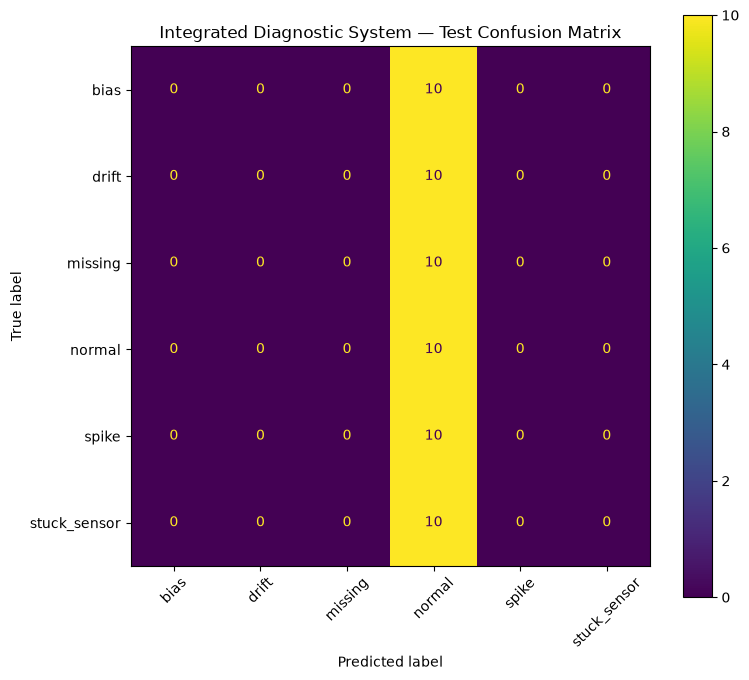

In [160]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay(
    confusion_matrix=integrated_cm,
    display_labels=fault_order
).plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title("Integrated Diagnostic System — Test Confusion Matrix")
plt.tight_layout()
plt.show()

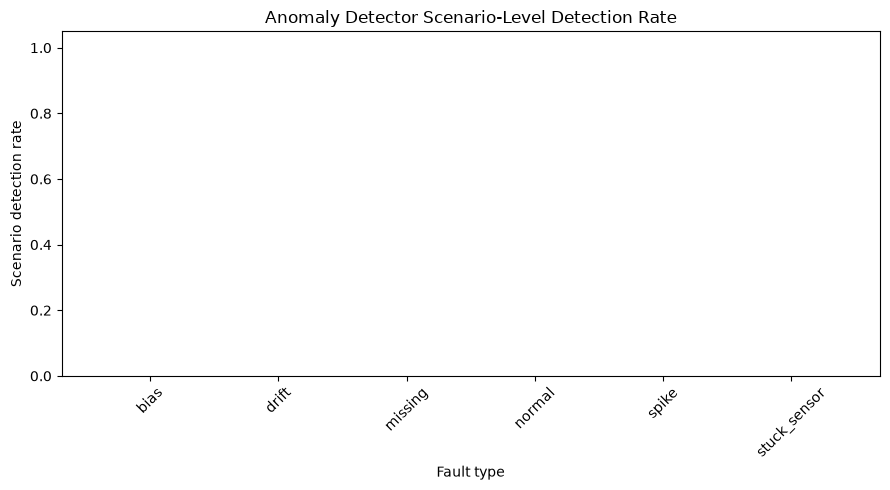

In [161]:
plot_df = integrated_by_fault.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["fault_type"],
    plot_df["anomaly_detection_rate"]
)

plt.ylim(0, 1.05)
plt.ylabel("Scenario detection rate")
plt.xlabel("Fault type")
plt.title("Anomaly Detector Scenario-Level Detection Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

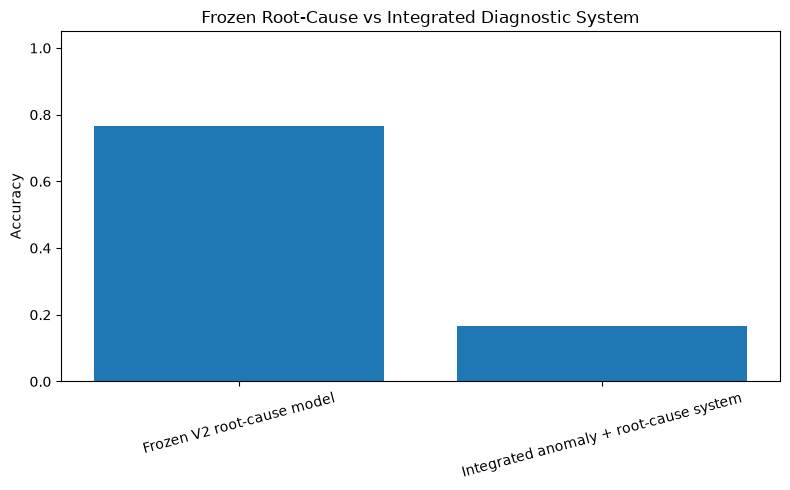

In [162]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["system"],
    comparison["accuracy"]
)

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Frozen Root-Cause vs Integrated Diagnostic System")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

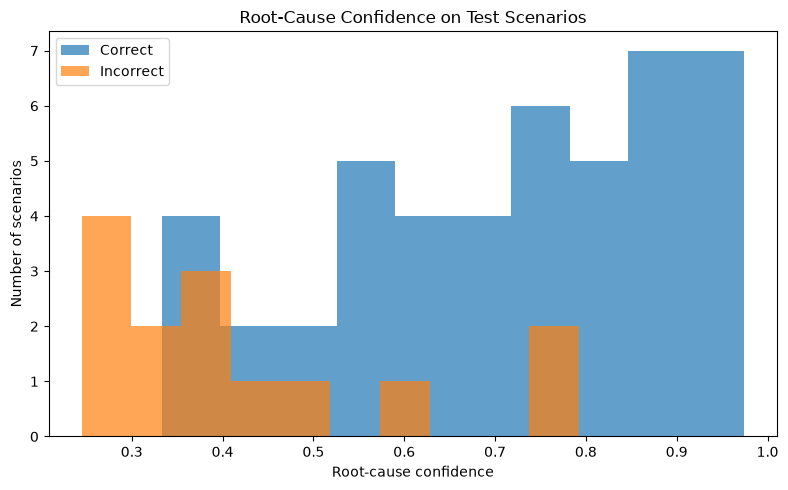

In [163]:
plt.figure(figsize=(8, 5))

plt.hist(
    integrated_test.loc[
        integrated_test["root_cause_correct"],
        "root_cause_confidence"
    ],
    bins=10,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    integrated_test.loc[
        ~integrated_test["root_cause_correct"],
        "root_cause_confidence"
    ],
    bins=10,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Root-cause confidence")
plt.ylabel("Number of scenarios")
plt.title("Root-Cause Confidence on Test Scenarios")
plt.legend()
plt.tight_layout()
plt.show()

In [164]:
high_confidence_errors = integrated_test[
    (~integrated_test["root_cause_correct"]) &
    (integrated_test["root_cause_confidence"] >= 0.70)
].copy()

display(
    high_confidence_errors[
        [
            "scenario_id",
            "fault_type",
            "predicted_fault",
            "root_cause_confidence",
            "scenario_detected",
            "integrated_prediction",
        ]
    ]
)

,scenario_id,fault_type,predicted_fault,root_cause_confidence,scenario_detected,integrated_prediction
1,7,normal,stuck_sensor,0.740492,False,normal
13,53,spike,normal,0.792648,False,normal


In [165]:
# ============================================================
# 12. FINAL PROJECT METRICS
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

final_root_accuracy = accuracy_score(
    integrated_test["fault_type"],
    integrated_test["predicted_fault"]
)

final_root_macro_f1 = f1_score(
    integrated_test["fault_type"],
    integrated_test["predicted_fault"],
    labels=fault_order,
    average="macro",
    zero_division=0
)

final_integrated_accuracy = accuracy_score(
    integrated_test["fault_type"],
    integrated_test["integrated_prediction"]
)

final_integrated_macro_f1 = f1_score(
    integrated_test["fault_type"],
    integrated_test["integrated_prediction"],
    labels=fault_order,
    average="macro",
    zero_division=0
)

final_summary = pd.DataFrame({
    "metric": [
        "Test scenarios",
        "Root-cause accuracy",
        "Root-cause macro F1",
        "Integrated accuracy",
        "Integrated macro F1",
        "Normal scenario false alarm rate",
    ],
    "value": [
        len(integrated_test),
        final_root_accuracy,
        final_root_macro_f1,
        final_integrated_accuracy,
        final_integrated_macro_f1,
        normal_false_alarm_rate,
    ]
})

display(final_summary)

,metric,value
0,Test scenarios,60.000000
1,Root-cause accuracy,0.766667
2,Root-cause macro F1,0.748583
3,Integrated accuracy,0.166667
4,Integrated macro F1,0.047619
5,Normal scenario false alarm rate,0.000000


In [166]:
# ============================================================
# 13. SAVE FINAL EVALUATION ARTIFACTS
# ============================================================

final_integrated_test = integrated_test.copy()

final_integrated_test.to_csv(
    "../data/final_integrated_diagnostic_test.csv",
    index=False
)

integrated_by_fault.to_csv(
    "../data/final_integrated_diagnostic_by_fault.csv",
    index=False
)

comparison.to_csv(
    "../data/final_root_cause_vs_integrated.csv",
    index=False
)

final_summary.to_csv(
    "../data/final_integrated_diagnostic_metrics.csv",
    index=False
)

print("Saved final evaluation artifacts:")
print("../data/final_integrated_diagnostic_test.csv")
print("../data/final_integrated_diagnostic_by_fault.csv")
print("../data/final_root_cause_vs_integrated.csv")
print("../data/final_integrated_diagnostic_metrics.csv")

Saved final evaluation artifacts:
../data/final_integrated_diagnostic_test.csv
../data/final_integrated_diagnostic_by_fault.csv
../data/final_root_cause_vs_integrated.csv
../data/final_integrated_diagnostic_metrics.csv


In [176]:
# ============================================================
# STEP 1 — CHECK THE VARIABLES WE ACTUALLY HAVE
# ============================================================

import numpy as np
import pandas as pd

print("Checking required variables...\n")

required = ["y_test"]

for var in required:
    if var in globals():
        print(f"✓ {var} exists")
        print(f"  type   : {type(globals()[var])}")
        print(f"  length : {len(globals()[var])}")
    else:
        print(f"✗ {var} does NOT exist")

print("\nVariables containing 'pred':")
pred_names = [name for name in list(globals().keys())
              if "pred" in name.lower()]

print(pred_names)

Checking required variables...

✓ y_test exists
  type   : <class 'pandas.Series'>
  length : 1440

Variables containing 'pred':
['val_pred_encoded', 'scenario_val_pred', 'scenario_val_pred_v2', 'scenario_val_pred_v2_labels', 'scenario_val_pred_v3', 'scenario_val_pred_v3_labels', 'scenario_test_pred_v2', 'scenario_test_pred_v2_labels', 'y_pred_anomaly', 'predicted', 'scenario_pred', 'predictions', 'prediction_candidates', 'y_pred_check']


In [177]:
# ============================================================
# STEP 2 — SHOW THE ACTUAL PREDICTION VARIABLES
# ============================================================

for name in pred_names:
    try:
        value = globals()[name]

        if isinstance(value, (list, tuple, np.ndarray, pd.Series)):
            print(f"\n{name}")
            print("  type :", type(value))
            print("  len  :", len(value))

            try:
                print("  unique:", np.unique(value))
            except:
                pass

    except Exception as e:
        print(f"{name}: could not inspect ({e})")


val_pred_encoded
  type : <class 'numpy.ndarray'>
  len  : 1440
  unique: [0 1 2 3 4 5]

scenario_val_pred
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: [0 1 2 3 4 5]

scenario_val_pred_v2
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: [0 1 2 3 4 5]

scenario_val_pred_v2_labels
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: ['bias' 'drift' 'missing' 'normal' 'spike' 'stuck_sensor']

scenario_val_pred_v3
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: [0 1 2 3 4 5]

scenario_val_pred_v3_labels
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: ['bias' 'drift' 'missing' 'normal' 'spike' 'stuck_sensor']

scenario_test_pred_v2
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: [0 1 2 3 4 5]

scenario_test_pred_v2_labels
  type : <class 'numpy.ndarray'>
  len  : 60
  unique: ['bias' 'drift' 'missing' 'normal' 'spike' 'stuck_sensor']

y_pred_anomaly
  type : <class 'pandas.Series'>
  len  : 7200
  unique: [False]

predicted
  type : <class 'pandas.Ser